## Objective:


The objective is to build a machine learning classification model to predict whether a customer will churn (i.e., stop using the company's services). 

<a id="toc"></a>

# Index

1. [Import Libraries/Dataset](#sec-1)
   - [a. Download the dataset](#sec-1a)
   - [b. Import the required libraries](#sec-1b)

2. [Data Visualization and Exploration](#sec-2)
   - [a. Print 2 rows for sanity check](#sec-2a)
   - [b. Provide appropriate data visualizations](#sec-2b)
     - [Target class assumption](#sec-2b1)
     - [Info / schema](#sec-2b2)
     - [Check for duplicates](#sec-2b3)
     - [Class distribution plots](#sec-2b4)
   - [c. Correlational analysis](#sec-2c)

3. [Data Pre-processing and Cleaning](#sec-3)
   - [a. Appropriate pre-processing](#sec-3a)
     - [Missing values](#sec-3a1)
     - [Outliers](#sec-3a2)
     - [Skewness](#sec-3a3)
   - [b. Feature engineering](#sec-3b)
     - [Encode categorical features](#sec-3b1)
     - [Drop CustomerID](#sec-3b2)
     - [Standardization](#sec-3b3)
     - [Feature importance](#sec-3b4)

4. [Model Building](#sec-4)
   - [a. Train–test split](#sec-4a)
   - [b. Models](#sec-4b)
     - [i. Logistic Regression](#sec-4b1)
     - [ii. Decision Tree](#sec-4b2)
     - [iii. K-Nearest Neighbors (KNN)](#sec-4b3)
     - [iv. Random Forest (Ensemble)](#sec-4b4)
   - [c. Hyperparameter tuning](#sec-4c)
     - [LR: C (regularization)](#sec-4c1)
     - [DT: max_depth, min_samples_split](#sec-4c2)
     - [KNN: n_neighbors, weights](#sec-4c3)
     - [RF: n_estimators, max_depth](#sec-4c4)
     - [Summary of best scores](#sec-4c5)

5. [Performance Evaluation](#sec-5)
   - [a. Compare performances](#sec-5a)
   - [b. Identify the best model](#sec-5b)

6. [Advanced Analysis](#sec-6)
   - [a. XGBoost](#sec-6a)
   - [b. XGBoost with DMatrix](#sec-6b)
   - [c. LightGBM](#sec-6c)
   - [d. Voting Classifier](#sec-6d)
   - [e. Stacking Classifier](#sec-6e)
   - [f. Best Ensemble Model](#sec-6f)

7. [Churn Prediction Model – Performance Analysis](#sec-7)


<a id="sec-1"></a>
# 1. Import Libraries/Dataset
[Back to Index](#toc)

<a id="sec-1a"></a>
## 1.a Download the dataset
[Back to Index](#toc)

In [95]:
# Pandas to Download the dataset
import pandas as pd

# Load the dataset in a dataframe
df_original = pd.read_csv('customer_churn_dataset.csv')
df = df_original.copy() #this is used for all the trainings

<a id="sec-1b"></a>
## 1.b Import the required libraries
[Back to Index](#toc)

In [2]:
# b. Import the required libraries

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Set visual style
sns.set(style='whitegrid')
import warnings
warnings.filterwarnings('ignore')

#Encoding
from sklearn.preprocessing import LabelEncoder
#Scaling
from sklearn.preprocessing import StandardScaler
# Use built-in sklearn tools for Feature Importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, chi2
#data split
from sklearn.model_selection import train_test_split
#Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier  # Chosen ensemble method
#Model evaluation report
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
#CV
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve
#Advanced Analysis
from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import early_stopping, log_evaluation

from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

<a id="sec-2"></a>
# 2. Data Visualization and Exploration
[Back to Index](#toc)

<a id="sec-2a"></a>
## 2.a Print 2 rows for sanity check
[Back to Index](#toc)

In [3]:
# We use the .sample() method of pandas DataFrame with n=2 
# to randomly pick 2 rows for a quick check.

df.sample(2, random_state=42)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,Churn
6252,Cust_6253,Male,0.0,No,Yes,NaN,NaN,No,Fiber optic,No internet service,No internet service,0
4684,Cust_4685,Female,1.0,Yes,Yes,63.0,Yes,Yes,Fiber optic,Yes,No internet service,0


- As we see from above rows, We have 12 features, includes "Churn" target variable.

<a id="sec-2b"></a>
## 2.b Provide appropriate data visualizations
[Back to Index](#toc)

In [5]:
#target variable count
print(df['Churn'].value_counts())

1    5020
0    4980
Name: Churn, dtype: int64


<a id="sec-2b1"></a>
### 2.b.1 Target class assumption
[Back to Index](#toc)

1 → Churned (customer left the service)

0 → Not Churned (customer stayed)

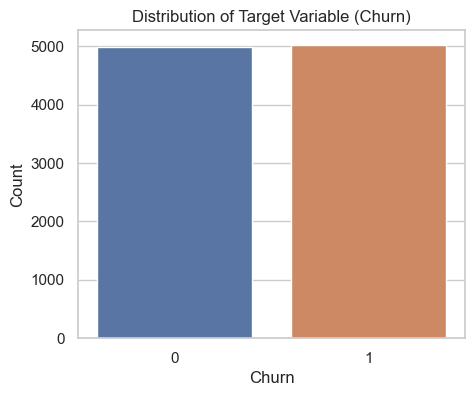

In [6]:
#Target variable distribution
plt.figure(figsize=(5, 4))
sns.countplot(x='Churn', data=df)
plt.title('Distribution of Target Variable (Churn)')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

- Almost perfect balanced target class "churn" & "non-churn" classes.

<a id="sec-2b2"></a>
### 2.b.2 Info / schema
[Back to Index](#toc)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customerID       10000 non-null  object 
 1   gender           9000 non-null   object 
 2   SeniorCitizen    9000 non-null   float64
 3   Partner          9000 non-null   object 
 4   Dependents       9000 non-null   object 
 5   tenure           9000 non-null   float64
 6   PhoneService     9000 non-null   object 
 7   MultipleLines    9000 non-null   object 
 8   InternetService  9000 non-null   object 
 9   OnlineSecurity   9000 non-null   object 
 10  OnlineBackup     9000 non-null   object 
 11  Churn            10000 non-null  int64  
dtypes: float64(2), int64(1), object(9)
memory usage: 937.6+ KB


- 10k records
- 12 features -> float-2, int-1 and object 9 data types
- 10 features have equal no.of missing values

<a id="sec-2b3"></a>
### 2.b.3 Duplicates
[Back to Index](#toc)

In [5]:
# Checking duplicated data
df.duplicated().any()

False

- No duplicated rows exist

##### Unique values in each feature 

In [7]:
#  Check the count and what unique values exist for each feature
for col in df.columns:
    print(f"Column: {col}")
    print(f"Num unique: {df[col].nunique()}")
    print("Unique values:", df[col].unique())
    print("-" * 40)

Column: customerID
Num unique: 10000
Unique values: ['Cust_1' 'Cust_2' 'Cust_3' ... 'Cust_9998' 'Cust_9999' 'Cust_10000']
----------------------------------------
Column: gender
Num unique: 2
Unique values: ['Male' 'Female' nan]
----------------------------------------
Column: SeniorCitizen
Num unique: 2
Unique values: [ 0.  1. nan]
----------------------------------------
Column: Partner
Num unique: 2
Unique values: ['Yes' 'No' nan]
----------------------------------------
Column: Dependents
Num unique: 2
Unique values: ['No' 'Yes' nan]
----------------------------------------
Column: tenure
Num unique: 72
Unique values: [ 2. nan 13. 55. 32. 22. 17. 70. 51.  8. 10. 19. 14. 67. 61. 56. 63. 47.
  6. 34. 65. 64. 31. 62. 54. 42. 41. 59. 40. 24. 38. 16. 45. 66. 46. 33.
 50.  7. 71.  4. 26. 69. 52. 72. 21. 18. 28. 37. 60. 11.  3. 29. 23. 12.
 35. 58. 57. 30. 27. 15. 39. 43.  5. 36. 49. 68.  1. 25. 44. 48. 20.  9.
 53.]
----------------------------------------
Column: PhoneService
Num unique

- CustomerID is unique for all 10k records
- tenure is also numerical and mutli valued column
- Churn - Target class - 1/0
- Some of them have 2 classes and some of them 3.

In [8]:
df.describe()

,SeniorCitizen,tenure,Churn
count,9000.000000,9000.000000,10000.000000
mean,0.500111,36.459889,0.502000
std,0.500028,20.691516,0.500021
min,0.000000,1.000000,0.000000
25%,0.000000,19.000000,0.000000
50%,1.000000,37.000000,1.000000
75%,1.000000,54.000000,1.000000
max,1.000000,72.000000,1.000000


Missing data: count is 9,000 for SeniorCitizen and tenure but 10,000 for Churn so about 10% missing in those two features.

Balanced target: Churn mean ~ 0.502 with std ~ 0.50 so the target is almost perfectly 50/50. 

Binary feature balance: SeniorCitizen mean ~ 0.50, std ~ 0.50 so the class is also evenly split

Tenure spread: tenure ranges 1–72 months, median ≈ 37, IQR 19–54, wide dispersion and roughly symmetric (mean = median). 

<a id="sec-2b4"></a>
### 2.b.4 Class distribution plots
[Back to Index](#toc)

In [23]:
#Distribution of numerical features
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

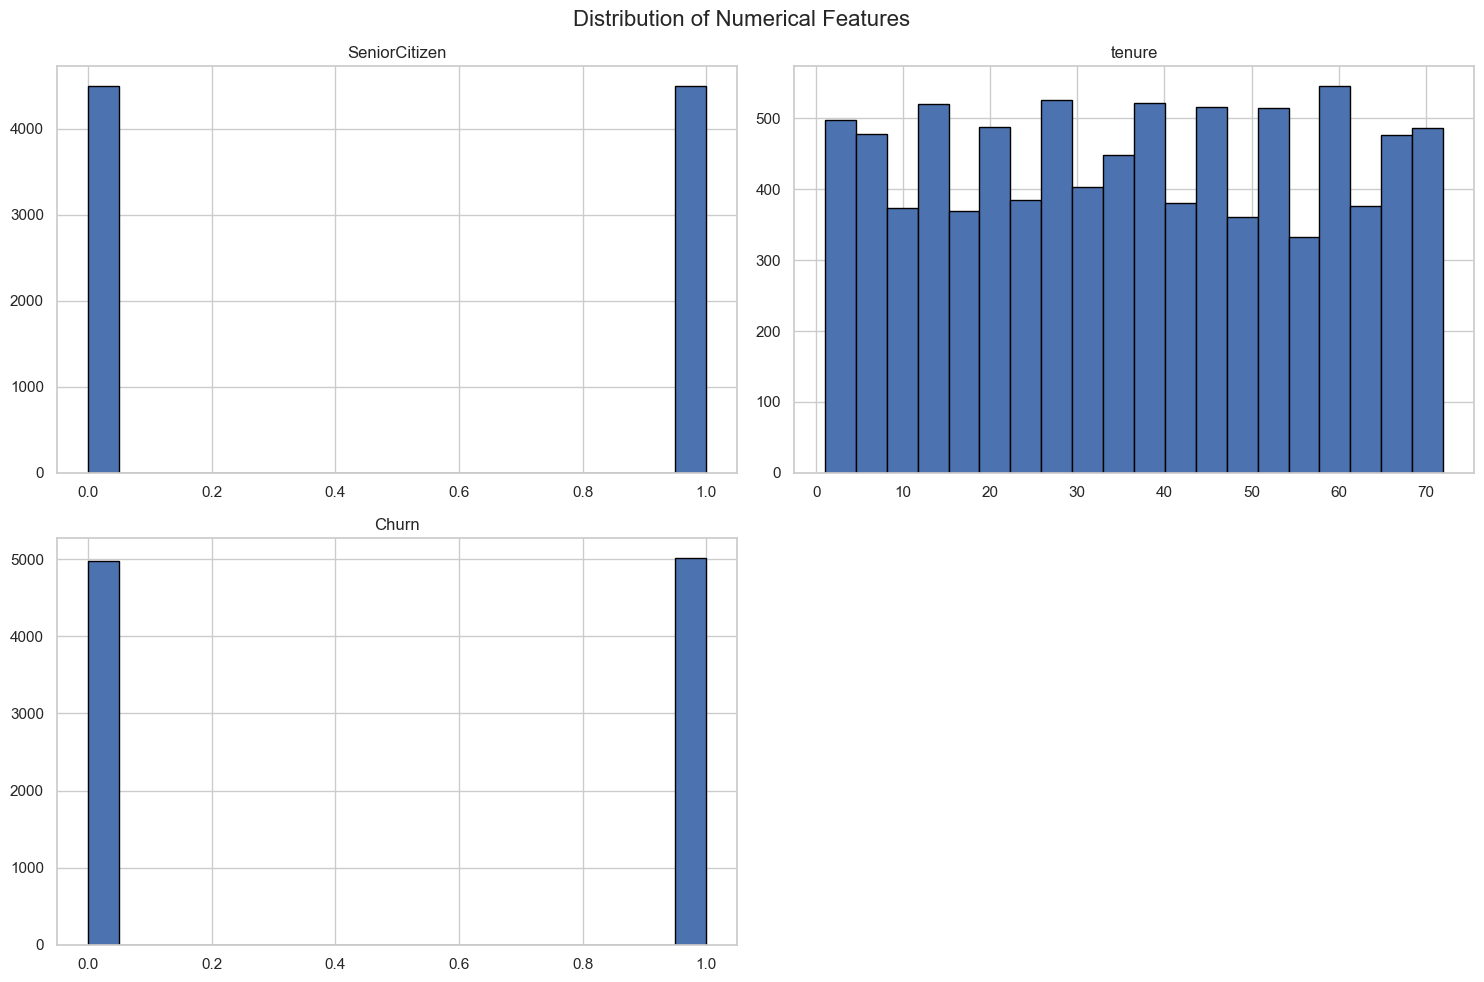

In [24]:
# Plot histograms for each numerical column
df[numerical_cols].hist(figsize=(15, 10), bins=20, edgecolor='black')
plt.suptitle('Distribution of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

- out of 12, we only have 3 numeric columns given. Samething we observed in sanity check as well.
- Churn, Senior Citizen - Binary variables - 0 & 1
- tenure is multi-valued column ranging from 0 to 70.
- tenure also almost uniformly distributed

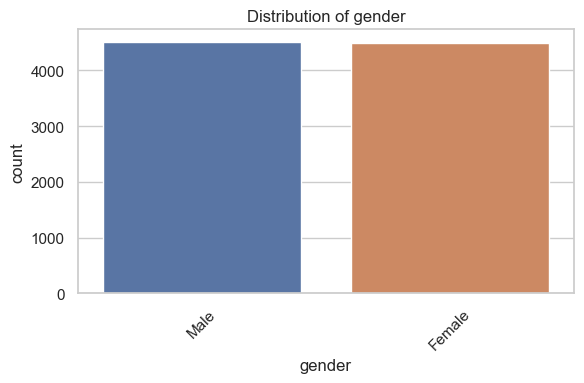

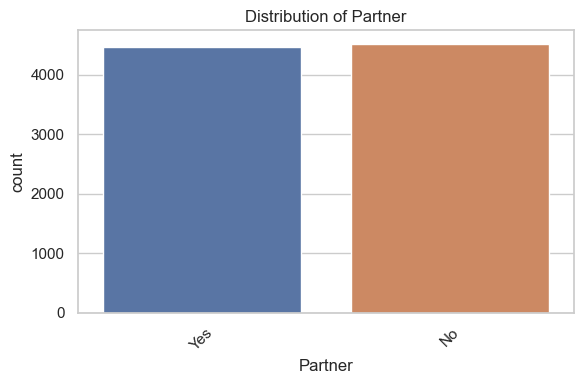

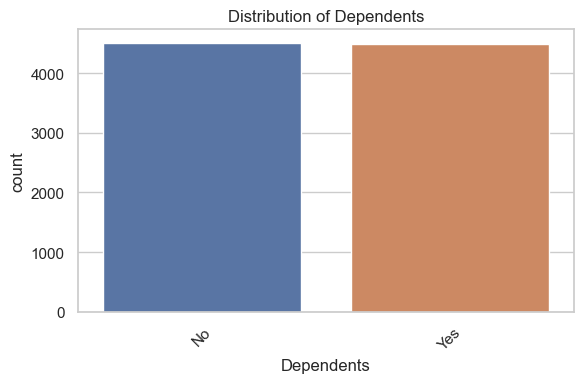

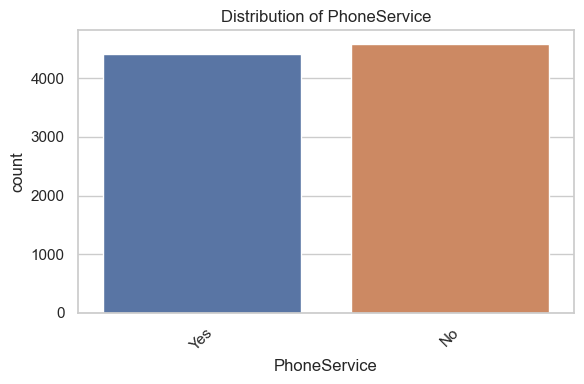

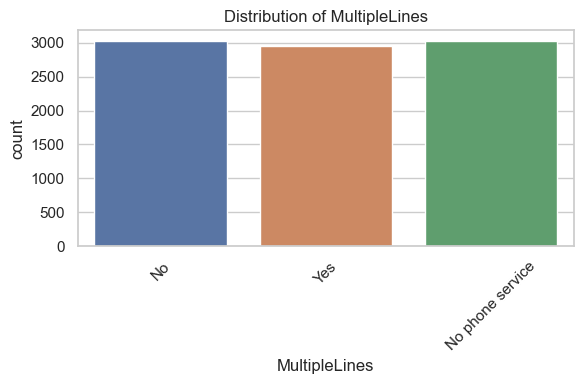

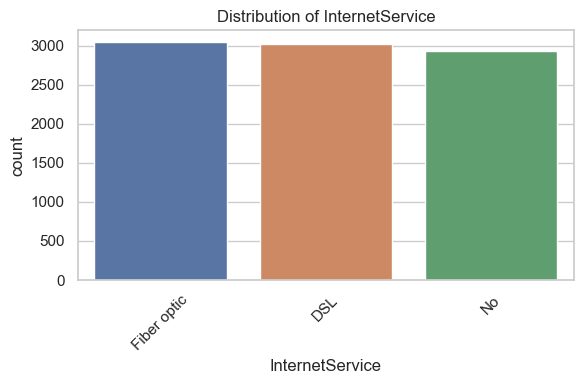

In [25]:
#Count plots for selected categorical features
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Remove 'customerID' if it's in the list (since it's an identifier)
categorical_cols = [col for col in categorical_cols if col.lower() != 'customerid']

# Plot first few categorical features
for col in categorical_cols[:6]:  # Adjust number as needed
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=df)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

- All categorical features are equally distributed 50%-50%
- There are multinomial variables exist starting from 3
 

In [19]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'Churn'],
      dtype='object')

##### Churn class distribution among given features

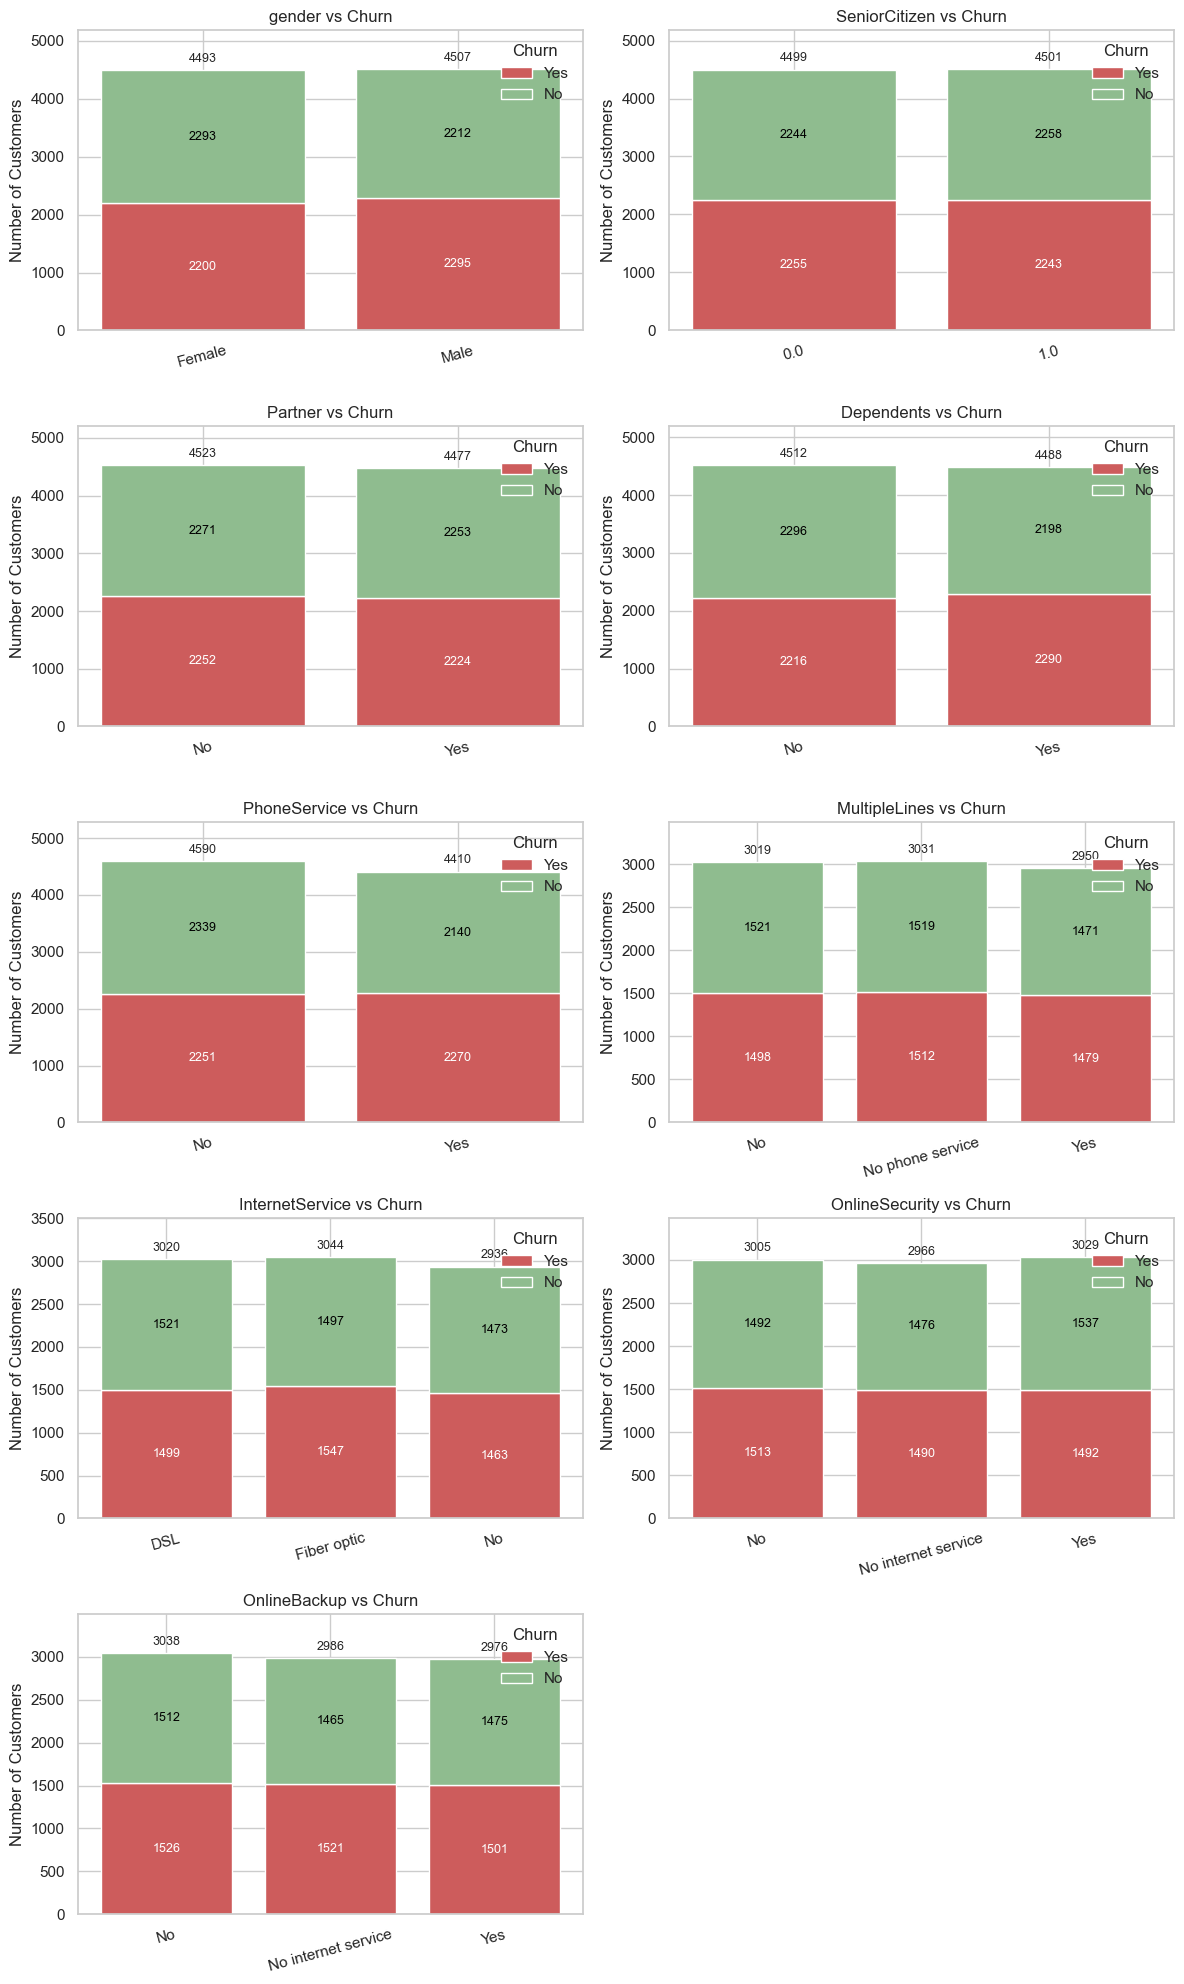

In [18]:
def plot_churn_stacks(df, cat_cols, target="Churn", pos_label="Yes", neg_label="No", ncols=2):

    data = df.copy()

    if pd.api.types.is_numeric_dtype(data[target]):
        data["_target_str"] = data[target].map({1: "Yes", 0: "No"})
    else:
        data["_target_str"] = data[target].astype(str).str.strip().str.title()  # yes/no -> Yes/No

    # Ensure expected order
    order_cols = ["Yes", "No"]
    if isinstance(pos_label, str):
        order_cols = [pos_label, neg_label]

    n = len(cat_cols)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows), squeeze=False)

    for i, col in enumerate(cat_cols):
        ax = axes[i // ncols, i % ncols]

        # Crosstab: counts of Yes/No per category
        ct = pd.crosstab(data[col], data["_target_str"]).reindex(columns=order_cols, fill_value=0)

        # Bars
        x = np.arange(len(ct))
        yes_counts = ct[order_cols[0]].values
        no_counts  = ct[order_cols[1]].values
        totals = yes_counts + no_counts

        ax.bar(x, yes_counts, color="indianred", label=order_cols[0])             # bottom segment
        ax.bar(x, no_counts,  bottom=yes_counts, color="darkseagreen", label=order_cols[1])  # top segment

        # Text labels inside segments
        for xi, yv in enumerate(yes_counts):
            if yv > 0:
                ax.text(xi, yv/2, f"{int(yv)}", ha="center", va="center", fontsize=9, color="white")
        for xi, (yb, yn) in enumerate(zip(yes_counts, no_counts)):
            if yn > 0:
                ax.text(xi, yb + yn/2, f"{int(yn)}", ha="center", va="center", fontsize=9, color="black")

        # Totals on top
        for xi, t in enumerate(totals):
            ax.text(xi, t + max(totals)*0.02, f"{int(t)}", ha="center", va="bottom", fontsize=9)

        # Cosmetics
        ax.set_title(f"{col} vs Churn")
        ax.set_xticks(x, ct.index.astype(str), rotation=15)
        ax.set_ylabel("Number of Customers")
        ax.margins(y=0.15)

        
        ax.legend(title="Churn", loc="upper right", frameon=False)

    # Hide any empty axes
    for j in range(n, nrows * ncols):
        fig.delaxes(axes[j // ncols, j % ncols])

    fig.tight_layout()
    plt.show()

cat_features = ["gender", "SeniorCitizen", "Partner", "Dependents",'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup']

plot_churn_stacks(df, cat_features, target="Churn", pos_label="Yes", neg_label="No", ncols=2)


- Each categorical feature nearly the same split (~50/50 churn vs no-churn).
- These features may not help in understanding the dataset
- Data seems so random



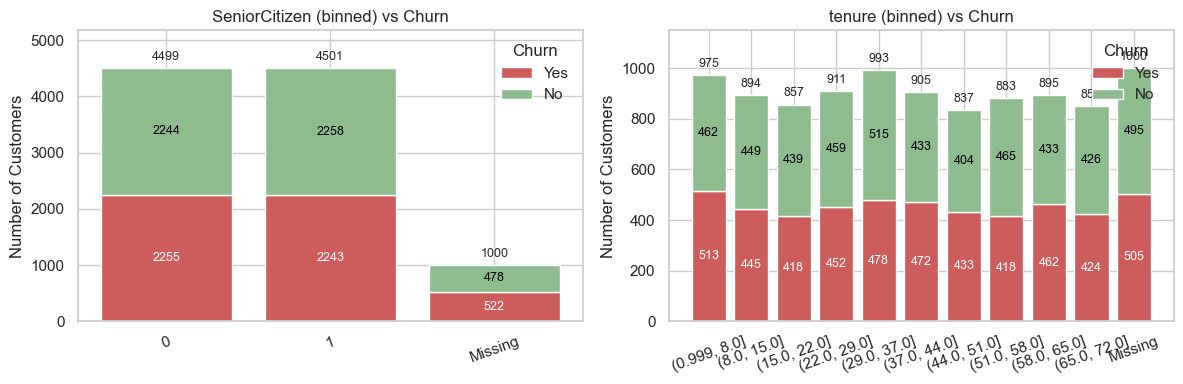

In [20]:
def _bin_series(s, bins=10, strategy="quantile"):

    s = pd.to_numeric(s, errors="coerce")
    # If it's already 'discrete' (e.g., 0/1), just treat as categories
    nunq = s.nunique(dropna=True)
    if nunq <= min(bins, 10):
        return s.astype("Int64").astype("category")

    if strategy == "quantile":
        # Drop duplicate bin edges automatically
        return pd.qcut(s, q=min(bins, nunq), duplicates="drop")
    else:
        edges = np.linspace(s.min(), s.max(), num=bins + 1)
        # Ensure unique edges
        edges = np.unique(edges)
        if len(edges) <= 2:
            return s.astype("Int64").astype("category")
        return pd.cut(s, bins=edges, include_lowest=True)

def plot_churn_stacks_numeric(
    df, num_cols, target="Churn", pos_label="Yes", neg_label="No",
    bins=10, strategy="quantile", ncols=2
):

    data = df.copy()


    if pd.api.types.is_numeric_dtype(data[target]):
        data["_target_str"] = data[target].map({1: "Yes", 0: "No"})
    else:
        data["_target_str"] = data[target].astype(str).str.strip().str.title()

    order_cols = [pos_label, neg_label] if isinstance(pos_label, str) else ["Yes", "No"]

    # Prepare layout
    n = len(num_cols)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows), squeeze=False)

    for i, col in enumerate(num_cols):
        ax = axes[i // ncols, i % ncols]

        binned = _bin_series(data[col], bins=bins, strategy=strategy)

        binned = binned.astype("object")
        binned = binned.where(~binned.isna(), "Missing")


        ct = pd.crosstab(binned, data["_target_str"]).reindex(columns=order_cols, fill_value=0)

        x = np.arange(len(ct))
        yes_counts = ct[order_cols[0]].values
        no_counts  = ct[order_cols[1]].values
        totals = yes_counts + no_counts

        ax.bar(x, yes_counts, color="indianred", label=order_cols[0])
        ax.bar(x, no_counts, bottom=yes_counts, color="darkseagreen", label=order_cols[1])


        for xi, yv in enumerate(yes_counts):
            if yv > 0:
                ax.text(xi, yv/2, f"{int(yv)}", ha="center", va="center", fontsize=9, color="white")
        for xi, (yb, yn) in enumerate(zip(yes_counts, no_counts)):
            if yn > 0:
                ax.text(xi, yb + yn/2, f"{int(yn)}", ha="center", va="center", fontsize=9, color="black")


        for xi, t in enumerate(totals):
            ax.text(xi, t + max(totals)*0.02, f"{int(t)}", ha="center", va="bottom", fontsize=9)

        # Cosmetics
        labels = [str(idx) for idx in ct.index]
        ax.set_title(f"{col} (binned) vs Churn")
        ax.set_xticks(x, labels, rotation=20)
        ax.set_ylabel("Number of Customers")
        ax.margins(y=0.15)
        ax.legend(title="Churn", loc="upper right", frameon=False)

    # Hide unused axes
    for j in range(n, nrows * ncols):
        fig.delaxes(axes[j // ncols, j % ncols])

    fig.tight_layout()
    plt.show()


numeric_features = df.select_dtypes(include=["number"]).columns.tolist()
numeric_features = [c for c in numeric_features if c != "Churn"]  # exclude target


plot_churn_stacks_numeric(df, numeric_features, target="Churn",
                          pos_label="Yes", neg_label="No",
                          bins=10, strategy="quantile", ncols=2)


- Same as categorical columns, Senior citizen also evenly distrubuted for target class
- Only tenure seems some effect on Target class

<a id="sec-2c"></a>
## 2.c Correlational analysis
[Back to Index](#toc)

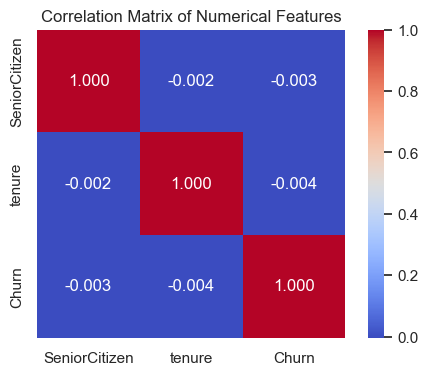

In [26]:
#Correlation heatmap of numerical features
plt.figure(figsize=(6, 4))
corr_matrix = df[numerical_cols].corr()

# Show 3 decimal places
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap='coolwarm', square=True)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

- All of them have very weak relationship among each other vs Target column. Almost negligible means unrelated.
- No column is impacting neither other column not target column.
- Since target class is balanced and looks like Churn is not having any correlation wrt any given feature
- No meaningful pattern will be found

###### Lets convert all categorical columns to numerical and plot correlation wrt Churn

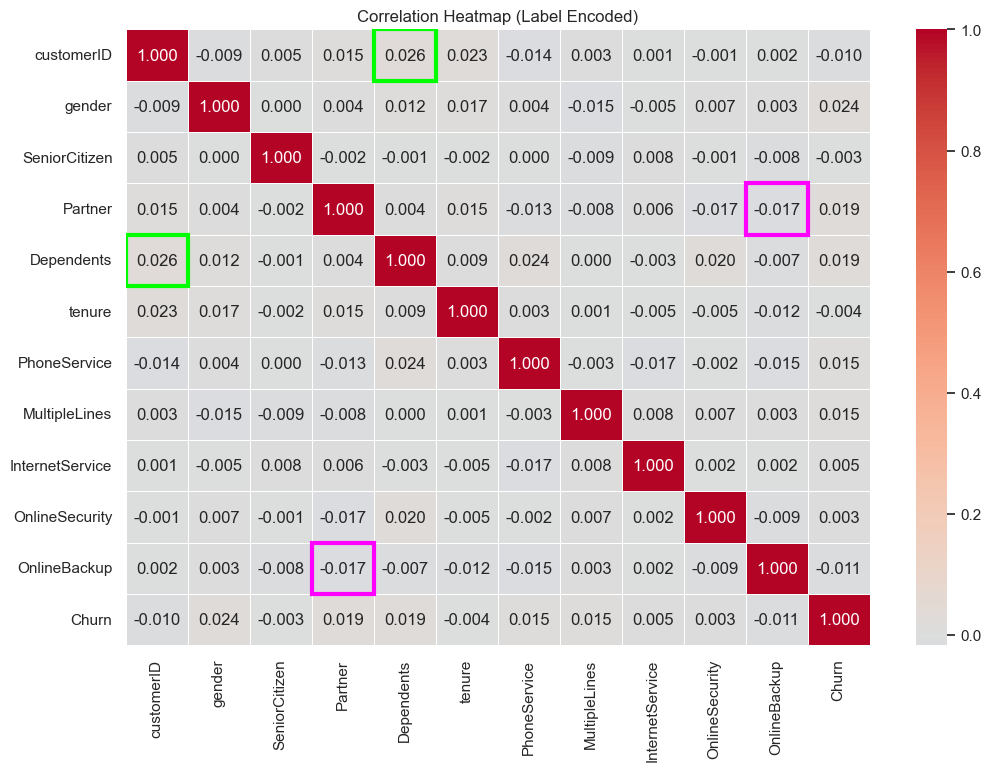

In [27]:
# Step 1: Label encode categorical columns
df_encoded = df.copy()
label_enc = LabelEncoder()

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = label_enc.fit_transform(df_encoded[col])

# Step 2: Compute correlation matrix
corr_matrix = df_encoded.corr()

# Step 3: Find max and min correlations (excluding diagonal)
mask = ~np.eye(corr_matrix.shape[0], dtype=bool)
max_val = corr_matrix.where(mask).max().max()
min_val = corr_matrix.where(mask).min().min()

# Step 4: Plot heatmap
plt.figure(figsize=(12, 8))
ax = sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar=True
)
plt.title("Correlation Heatmap (Label Encoded)")

# Step 5: Highlight max and min correlation cells
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if val == max_val and i != j:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='lime', lw=3))
        elif val == min_val and i != j:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='magenta', lw=3))

plt.show()


<b>Correlation analysis:</b>

 1. No multicollinearity found in given data.
 
 2. We see no significant correlation. Highest correlation postive 0.026 & negative -0.017. These are so insignificant. Churn is completely unpredictble with given columns.  

 3. All given feature are non-redundant features. No need to drop any.

 4. Worrying part is we found no correlation between features vs target column as well. Means no feature have impact on Churn/NotChurn. So model may not find any pattern since there isn't any.

<a id="sec-3"></a>
# 3. Data Pre-processing and Cleaning
[Back to Index](#toc)

<a id="sec-3a"></a>
## 3.a Appropriate pre-processing
[Back to Index](#toc)

<a id="sec-3a1"></a>
### 3.a.1 Missing values
[Back to Index](#toc)

In [97]:
# Check for missing values
df.isnull().sum()

customerID            0
gender             1000
SeniorCitizen      1000
Partner            1000
Dependents         1000
tenure             1000
PhoneService       1000
MultipleLines      1000
InternetService    1000
OnlineSecurity     1000
OnlineBackup       1000
Churn                 0
dtype: int64

- CustomerID makes no sense for Churn anyway. 
- Except CustomerID, all of the features have NULL values.
- 10% of each feature has NULL, its significant.
- <b> Instead of dropping them, lets fill them mode(categorical) or based on skewness mean or median(numerical) </b>

In [98]:
#Handling Missing Values

# - If categorical: fill with mode (most frequent)
# - If numerical: fill with mean or median (based on skewness)

#separate categorical and numerical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=np.number).columns.tolist()

#Fill missing categorical columns with mode
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

# Fill missing numerical columns based on skewness
for col in num_cols:
    if df[col].isnull().sum() > 0:
        if df[col].skew() > 1:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mean(), inplace=True)


* Mean is sensitive to outliers → not ideal for skewed data.

* Median is robust to outliers → better for skewed data.

* Mode is used for categorical data.

In [99]:
#Re-check the NULL now.
df.isnull().sum()

customerID         0
gender             0
SeniorCitizen      0
Partner            0
Dependents         0
tenure             0
PhoneService       0
MultipleLines      0
InternetService    0
OnlineSecurity     0
OnlineBackup       0
Churn              0
dtype: int64

<a id="sec-3a2"></a>
### 3.a.2 Outliers
[Back to Index](#toc)

Outliers can skew the model learning and hurt performance

 IQR = Q3 - Q1
 Anything outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR] is treated as outlier.

In [31]:
#Detecting and Handling Outliers using IQR

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f'{col}: {len(outliers)} outliers detected')


SeniorCitizen: 0 outliers detected
tenure: 0 outliers detected
Churn: 0 outliers detected


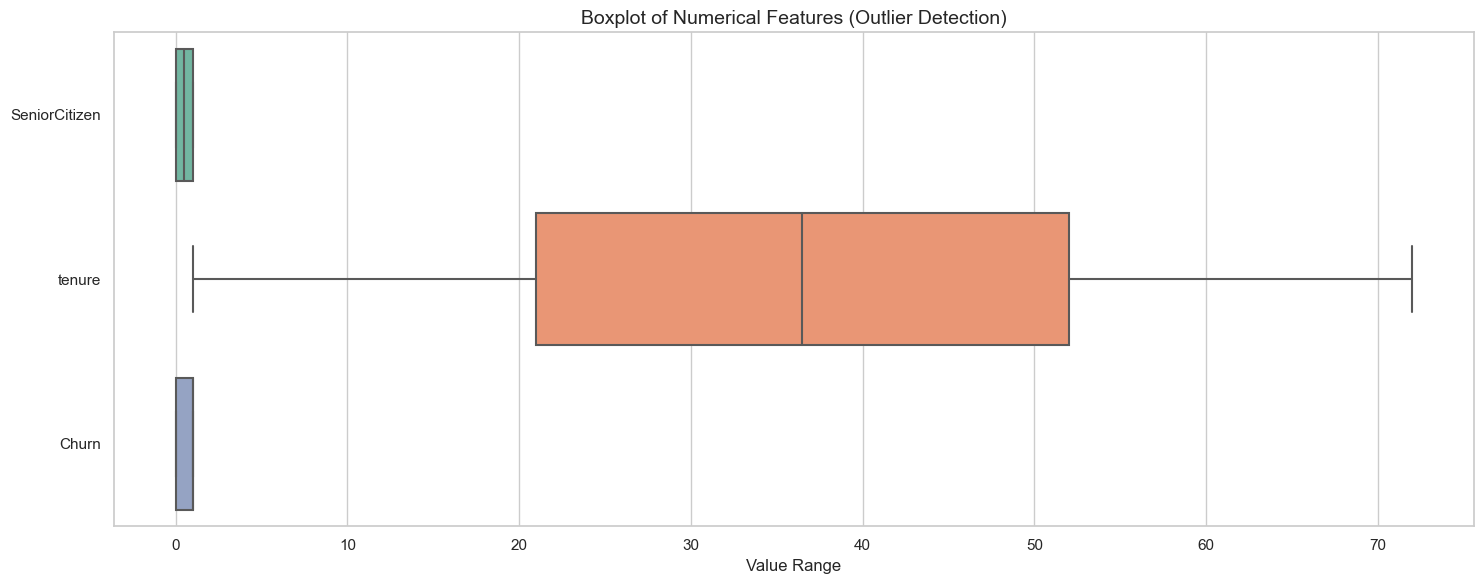

In [32]:
# Select only numerical columns
numeric_cols = df.select_dtypes(include='number').columns

# Set plot size
plt.figure(figsize=(15, 6))

# Create boxplot
sns.boxplot(data=df[numeric_cols], orient='h', palette='Set2')

plt.title("Boxplot of Numerical Features (Outlier Detection)", fontsize=14)
plt.xlabel("Value Range")
plt.tight_layout()
plt.show()


- Except Tenure, all binary valued columns. Tenure also don't have outliers.
- We don't find any potential or extream outliers in given data

<a id="sec-3a3"></a>
### 3.a.3 Skewness
[Back to Index](#toc)

Skewness is a measure of the asymmetry of the data distribution:

    Skewness ≈ 0 → Distribution is normal/symmetric

    Skewness > 1 or < -1 → Highly skewed (right or left tail is long)

- Highly skewed numerical features affect model performance.
- Especially important for models assuming normal distribution.

In [33]:
#Detecting Skewness
skew_values = df[num_cols].skew().sort_values(ascending=False)
print("Skewness of Numerical Columns:")
print(skew_values)


Skewness of Numerical Columns:
tenure           0.003687
SeniorCitizen   -0.000469
Churn           -0.008001
dtype: float64


- Skewness almost near to ZERO, so no negligible
- These follows Normal or symmetric distribution

#### Preprocessing Summary:

1. Missing Values: Checked using .isnull().sum().

    Filled missing values in:

        Categorical columns using mode

        Numerical columns using mean (for symmetric) or median (for skewed)

2. Outliers: Detected using IQR method. Count of outliers printed per feature.

    No outlier detected

3. Skewness: Checked skewness values of numerical columns.

    Columns with skew > 1 or < -1 marked as highly skewed.
    No skewness found in given data.

<a id="sec-3b"></a>
## 3.b Feature engineering
[Back to Index](#toc)

<a id="sec-3b2"></a>
### 3.b.2 Drop CustomerID
[Back to Index](#toc)

 Drop 'customerID' because it's an identifier and not useful for prediction.

In [34]:
# Drop 'customerID'
df.drop('customerID', axis=1, inplace=True)

<a id="sec-3b1"></a>
### 3.b.1 Encode categorical features
[Back to Index](#toc)

In [35]:
#Use pandas' get_dummies() for One-Hot Encoding (automatic)

# Convert target variable if it's categorical ('Yes'/'No' to 1/0)
if df['Churn'].dtype == 'object':
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Apply One-Hot Encoding to all categorical columns
df_encoded = pd.get_dummies(df, drop_first=True)

print(f"Data shape after encoding: {df_encoded.shape}")


Data shape after encoding: (10000, 15)


Why One-Hot Encoding used?

    One-Hot Encoding don't implying rank or order between categories (which would happen with label encoding).
    One-Hot Encoding prevents misleading the model (e.g., encoding DSL=0, Fiber=1, No=2 would make it like “No” > “DSL”)

<a id="sec-3b3"></a>
### 3.b.3 Standardization
[Back to Index](#toc)

##### Standardization and Normalization

- **Standardization**: (x - mean)/std -> for symmetric distributions
- **Normalization**: scales data to [0, 1] -> better for skewed data


Since we have no skewness in our data, lets use StandardScaler.

In [36]:
#StandardScaler

# Separate features and target
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled_df.head()


,SeniorCitizen,tenure,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes
0,-1.054327,-1.755595,0.903256,1.110693,-0.902343,1.125866,-0.821780,-0.646869,1.213589,-0.644693,-0.649358,-0.821439,1.532632,-0.650915
1,1.053858,0.000000,-1.107106,-0.900339,-0.902343,1.125866,-0.821780,-0.646869,1.213589,-0.644693,-0.649358,1.217376,-0.652472,1.536299
2,-1.054327,0.000000,0.903256,-0.900339,1.108226,-0.888205,-0.821780,1.545908,1.213589,-0.644693,-0.649358,-0.821439,-0.652472,-0.650915
3,1.053858,-1.195189,0.903256,-0.900339,-0.902343,1.125866,1.216871,-0.646869,1.213589,-0.644693,-0.649358,-0.821439,-0.652472,-0.650915
4,1.053858,0.944546,0.903256,1.110693,1.108226,-0.888205,-0.821780,-0.646869,1.213589,-0.644693,-0.649358,1.217376,-0.652472,1.536299


<a id="sec-3b4"></a>
### 3.b.4 Feature importance
[Back to Index](#toc)

- Knowing which features are most important helps reduce dimensionality,
- It improve training speed, and interpret models.

- Random Forest for tree-based importance

   - It provides a natural measure of feature importance.
   - RF tracks how much each feature reduces impurity (Gini or Entropy) across trees and averaging the contribution over all trees.
   - It captures non-linear relationships.
   - It works well for mixed-type data (categorical + numerical).
    
    
- SelectKBest for univariate selection

  - SelectKBest selects the top K features based on univariate statistical tests (like chi², ANOVA F-value, mutual info, etc.) between each feature and the target.
  - Simple and fast to filter top features before modeling.

In [37]:
# Random Forest feature importances
rf = RandomForestClassifier(random_state=42)
rf.fit(X_scaled_df, y)

# Create a feature importance DataFrame
rf_importances = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_})
rf_importances.sort_values(by='Importance', ascending=False, inplace=True)

# Display top 10
print("Top 10 Important Features (Random Forest):")
print(rf_importances.head(10))


Top 10 Important Features (Random Forest):
                               Feature  Importance
1                               tenure    0.524567
0                        SeniorCitizen    0.065326
3                          Partner_Yes    0.043364
4                       Dependents_Yes    0.040098
5                     PhoneService_Yes    0.038585
2                          gender_Male    0.037863
6       MultipleLines_No phone service    0.033772
13                    OnlineBackup_Yes    0.032929
11                  OnlineSecurity_Yes    0.032286
10  OnlineSecurity_No internet service    0.032109


- Tenure is most important feature for predicting Churn/NotChurn
- Tenure is only relavant data and all other features have no impact on Churn
- We have seen the same in covarinace correlation matrix as well.

##### Visualize Feature Importance

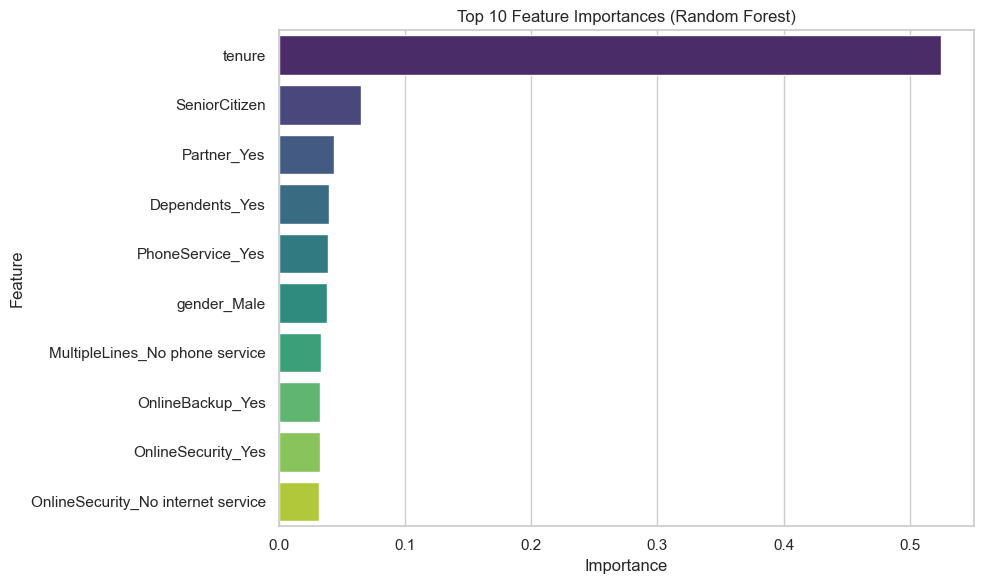

In [38]:
# Visualize top 10 feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=rf_importances.head(10), palette='viridis')
plt.title("Top 10 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()


##### Feature Engineering Summary

Dropped "CustomerID" - so irrelavant feature.

Encoding: All categorical features were one-hot encoded using get_dummies.

Standardization: Used StandardScaler because models like logistic regression and SVM are sensitive to feature scaling.

Feature Importance: Used Random Forest to rank features based on their predictive power. We find given columns are unrelated to Target variable.

<a id="sec-4"></a>
# 4. Model Building
[Back to Index](#toc)

<a id="sec-4a"></a>
## 4.a Train–test split
[Back to Index](#toc)

i.	Train = 80 % Test = 20% 

ii.	Also, try to split the dataset with different ratios of your choice.


##### Split the dataset into Training and Test Sets (80/20)

 To evaluate model performance on unseen data, we divide the dataset into:
 - Training Set: used to fit the model
 - Test Set: used to assess generalization performance

 80/20 is a commonly used ratio in ML because:
 - 80% gives sufficient data to train even complex models
 - 20% gives a reasonable sample size to validate performance
 
 
 Using sklearn's train_test_split with  <b> stratification to preserve class distribution </b>

In [39]:
# Standard 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y, test_size=0.2, random_state=42, stratify=y
)

print(f"80/20 Split → Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")


80/20 Split → Train size: 8000, Test size: 2000


<a id="sec-4b"></a>
## 4.b Models
[Back to Index](#toc)

i.	Logistic Regression

ii.	Decision tree

iii.	K-Nearest Neighbour

iv.	Ensemble Methods (any one of your choice)


<b> Functions for Evaluation </b>

In [43]:
def plot_confusion_matrix_heatmap(y_true, y_pred, class_labels=('No Churn (0)', 'Churn (1)')):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 2))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title('Confusion Matrix Heatmap')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

def plot_roc_curve(y_true, y_score, title='ROC Curve'):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc_val = roc_auc_score(y_true, y_score)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'AUC = {auc_val:.3f}')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1)  # random baseline
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def evaluate_model(model, X_train, X_test, y_train, y_test):
    # Fit the model
    model.fit(X_train, y_train)

    # Predict class labels
    y_pred = model.predict(X_test)

    #ROC–AUC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]        
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)          
    else:
        y_score = None                                    

    print(f"\nModel: {model.__class__.__name__}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

    plot_confusion_matrix_heatmap(y_test, y_pred)

    if y_score is not None:
        print("ROC-AUC:", roc_auc_score(y_test, y_score))
        plot_roc_curve(y_test, y_score, title=f'ROC Curve - {model.__class__.__name__}')
    else:
        print("ROC-AUC skipped: model has neither predict_proba nor decision_function.")


<a id="sec-4b1"></a>
### 4.b.i Logistic Regression
[Back to Index](#toc)

 Logistic Regression is a fundamental linear classification model,useful for baseline performance and interpretability.


Model: LogisticRegression
Accuracy: 0.501
Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.47      0.49       996
           1       0.50      0.53      0.51      1004

    accuracy                           0.50      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.50      0.50      0.50      2000



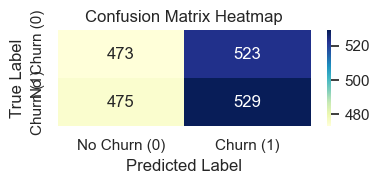

ROC-AUC: 0.49667394678314847


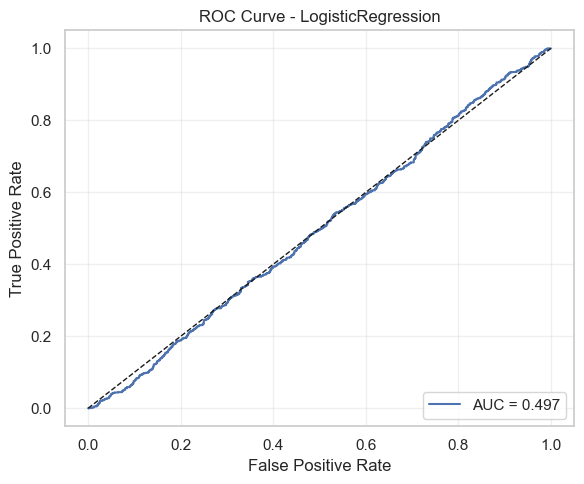

In [42]:
# Logistic Regression

log_model = LogisticRegression(max_iter=1000, random_state=42)
evaluate_model(log_model, X_train, X_test, y_train, y_test)


- The overall accuracy is 50.1%, which suggests that the model is not learning any meaningful patterns from the data
- It is likely predicting both classes almost equally without real discrimination.
- From Confusion Matrix, the model is making nearly equal errors in both classes.
- Precision, Recall, and F1-Score are all almost 0.50, shows no class imbalance handling and no benefit of prediction for either class
- This poor performance is not due to class imbalance, but rather due to a weak model fit.
- An AUC near 0.5 means the model’s scores can’t separate churners from non-churners

<b> Coefficients </b>

<b> Positive Coefficients:</b> These features increase the likelihood of the customer churning (i.e., the target = 1).

<b> Negative Coefficients:</b> These features reduce the likelihood of churn (i.e., push prediction toward 0 = no churn).
    
Larger absolute values (positive or negative) indicate a stronger influence on the prediction.

Small values close to 0 mean the feature has little effect on the model’s decision boundary.

In [44]:
# Display coefficients
coefficients = log_model.coef_[0]  # For binary classification, only one row
features = X_train.columns

coef_df = pd.DataFrame({'Feature': features, 'Coefficient': coefficients})
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

print("\nLogistic Regression Coefficients:\n")
print(coef_df.to_string(index=False))


Logistic Regression Coefficients:

                           Feature  Coefficient
                  PhoneService_Yes     0.055021
  OnlineBackup_No internet service     0.041769
                       gender_Male     0.039976
                    Dependents_Yes     0.035441
       InternetService_Fiber optic     0.027028
                     SeniorCitizen     0.017209
                  OnlineBackup_Yes     0.016816
                InternetService_No     0.016463
                OnlineSecurity_Yes     0.010212
    MultipleLines_No phone service     0.004966
OnlineSecurity_No internet service     0.003496
                 MultipleLines_Yes    -0.003721
                       Partner_Yes    -0.023135
                            tenure    -0.026700


- Tenure is a strong negative predictor – customers who have been with the company longer are much less likely to churn.

- Phone services and backup services seem to positively correlate with churn, perhaps due to dissatisfaction with those services.

- Demographic features like gender and Partner status play a subtle but notable role.

- Internet-related features show mixed behavior (fiber optic users slightly more churn, but not conclusive here).

<a id="sec-4b2"></a>
### 4.b.ii Decision Tree
[Back to Index](#toc)


- Decision Trees handle non-linear relationships well and are easy to visualize.
- They also work without feature scaling, but we use scaled data for consistency.


Model: DecisionTreeClassifier
Accuracy: 0.4915
Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.52      0.50       996
           1       0.49      0.47      0.48      1004

    accuracy                           0.49      2000
   macro avg       0.49      0.49      0.49      2000
weighted avg       0.49      0.49      0.49      2000



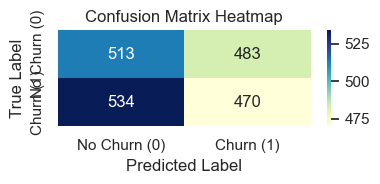

ROC-AUC: 0.49483241731867705


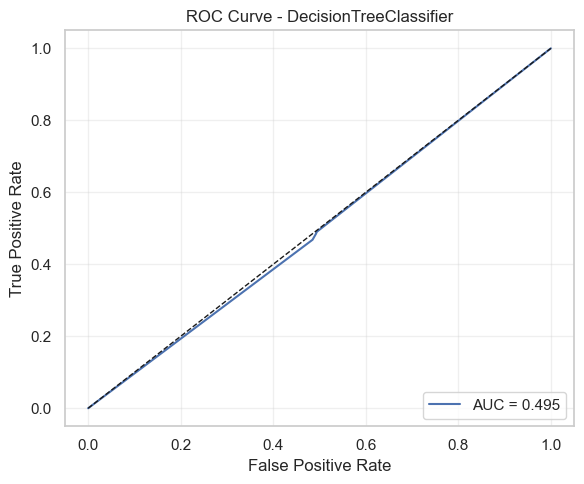

In [45]:
# Decision Trees

dt_model = DecisionTreeClassifier(random_state=42)
evaluate_model(dt_model, X_train, X_test, y_train, y_test)


- Accuracy = 49.15%, which is worse than a random guess (50%).
- The model is unable to effectively distinguish between churn and non-churn customers.
- True Churn (1) misclassified as No Churn (0): 534 times
  True No Churn (0) misclassified as Churn (1): 483 times
  
- An AUC near 0.5 means the model’s scores can’t separate churners from non-churners

  Indicates that the model is confused between the classes and lacks predictive power.


<a id="sec-4b3"></a>
### 4.b.iii K-Nearest Neighbors (KNN)
[Back to Index](#toc)

KNN is a simple and intuitive non-parametric method that classifies based on proximity.
It is sensitive to feature scaling, which we’ve already handled.


Model: KNeighborsClassifier
Accuracy: 0.488
Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.49      0.49       996
           1       0.49      0.48      0.49      1004

    accuracy                           0.49      2000
   macro avg       0.49      0.49      0.49      2000
weighted avg       0.49      0.49      0.49      2000



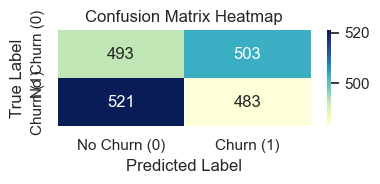

ROC-AUC: 0.48400324405190487


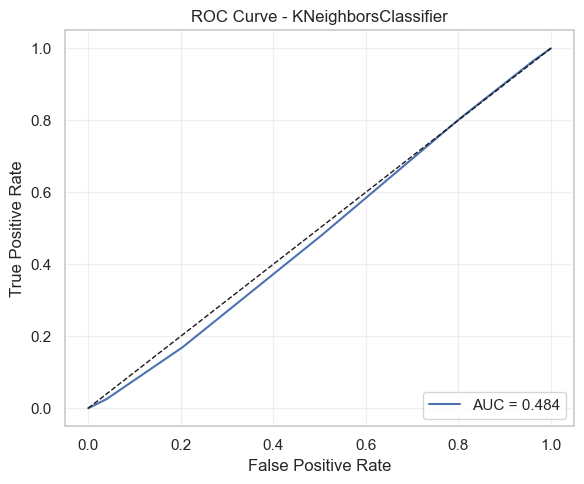

In [46]:
#KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
evaluate_model(knn_model, X_train, X_test, y_train, y_test)


- Accuracy = 0.488, which is lower than random forest (i.e., 50%).The model fails to distinguish churn vs. non-churn effectively.
- High False Positives (503) and False Negatives (521) indicate poor prediction quality for both classes.
- The classifier struggles equally on both types of errors.
- All scores hover around 0.49, showing the model is unable to prefer either class effectively.

<a id="sec-4b4"></a>
### 4.b.iv Random Forest (Ensemble)
[Back to Index](#toc)
 
- Random Forest is an ensemble of decision trees — it improves accuracy and reduces overfitting.
- Suitable for both linear and complex nonlinear patterns.


Model: RandomForestClassifier
Accuracy: 0.487
Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.52      0.50       996
           1       0.49      0.45      0.47      1004

    accuracy                           0.49      2000
   macro avg       0.49      0.49      0.49      2000
weighted avg       0.49      0.49      0.49      2000



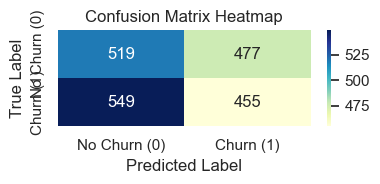

ROC-AUC: 0.4881103097649562


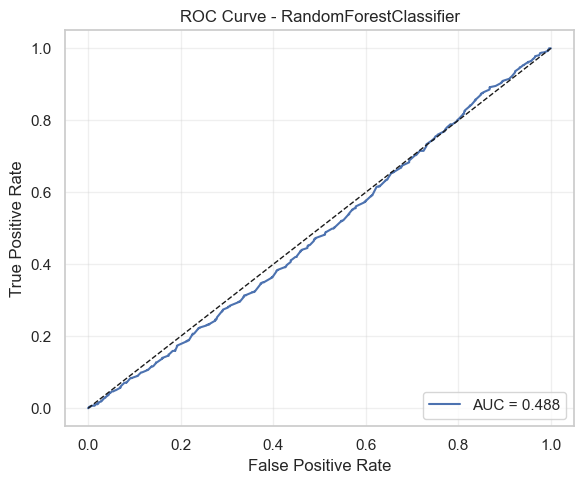

In [47]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
evaluate_model(rf_model, X_train, X_test, y_train, y_test)


- False Negatives (549) are high — the model is failing to detect churn.
- False Positives (477) are also significant — customers who wouldn’t churn are wrongly flagged.
- The model is struggling equally on both classes.
- No class is favored by the model.
- Model cannot capture true patterns in the data for meaningful classification.
- Features used may not carry enough predictive signal.


<a id="sec-4c"></a>
## 4.c Hyperparameter tuning
[Back to Index](#toc)

##### Why cross-validation?

 - Cross-validation (CV) ensures that the model performs well across different data subsets and avoids overfitting to a single train/test split.

 - <b> GridSearchCV </b> systematically tries combinations of hyperparameters and evaluates each using cross-validation (e.g., 5-fold CV)




<a id="sec-4c1"></a>
### 4.c.1 LR: C (regularization)
[Back to Index](#toc)

- C is the inverse of regularization strength.
- Lower C = more regularization (prevents overfitting), higher C = less regularization.

In [48]:
#Logistic Regression
param_grid_log = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2']
}

log_reg = LogisticRegression(max_iter=1000, random_state=42)
grid_log = GridSearchCV(log_reg, param_grid_log, cv=5, scoring='accuracy')
grid_log.fit(X_train, y_train)

print("Best Params (Logistic Regression):", grid_log.best_params_)
print("Best CV Score:", grid_log.best_score_)


Best Params (Logistic Regression): {'C': 1, 'penalty': 'l2'}
Best CV Score: 0.509125


<a id="sec-4c2"></a>
### 4.c.2 DT : max_depth, min_samples_split
[Back to Index](#toc)

- max_depth limits how deep the tree can grow -> controls overfitting
- min_samples_split determines the minimum number of samples required to split a node

In [50]:
#Decision Tree
param_grid_dt = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

dt = DecisionTreeClassifier(random_state=42)
grid_dt = GridSearchCV(dt, param_grid_dt, cv=5, scoring='accuracy')
grid_dt.fit(X_train, y_train)

print("Best Params (Decision Tree):", grid_dt.best_params_)
print("Best CV Score:", grid_dt.best_score_)


Best Params (Decision Tree): {'max_depth': 10, 'min_samples_split': 10}
Best CV Score: 0.50675


<a id="sec-4c3"></a>
### 4.c.3 KNN: n_neighbors, weights
[Back to Index](#toc)

- n_neighbors: Controls how many neighbors vote -> affects bias-variance tradeoff
- weights: 'uniform' (all neighbors equal) vs 'distance' (closer neighbors weighted more)

In [51]:
#KNN
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance']
}

knn = KNeighborsClassifier()
grid_knn = GridSearchCV(knn, param_grid_knn, cv=5, scoring='accuracy')
grid_knn.fit(X_train, y_train)

print("Best Params (KNN):", grid_knn.best_params_)
print("Best CV Score:", grid_knn.best_score_)


Best Params (KNN): {'n_neighbors': 3, 'weights': 'distance'}
Best CV Score: 0.50675


<a id="sec-4c4"></a>
### 4.c.4 RF: n_estimators, max_depth
[Back to Index](#toc)

- n_estimators: number of trees in the forest -> more trees = better performance, slower training
- max_depth: limits how deep each tree grows -> controls overfitting


In [52]:
# RF
param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, None]
}

rf = RandomForestClassifier(random_state=42)
grid_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='accuracy')
grid_rf.fit(X_train, y_train)

print("Best Params (Random Forest):", grid_rf.best_params_)
print("Best CV Score:", grid_rf.best_score_)


Best Params (Random Forest): {'max_depth': None, 'n_estimators': 50}
Best CV Score: 0.5113749999999999


<a id="sec-4c5"></a>
### 4.c.5 Summary of best scores
[Back to Index](#toc)

In [53]:
def summarize_grids(grid_pairs, sort_by="Best CV Score", ascending=False, decimals=6):
    rows = []
    for name, grid in grid_pairs:
        if not hasattr(grid, "best_params_"):
            continue
        scoring = getattr(grid, "scoring", None)
        scoring_name = scoring if isinstance(scoring, str) else (
            getattr(scoring, "__name__", None) if scoring else None
        )
        rows.append({
            "Model": name,
            "Best CV Score": float(grid.best_score_),
            "Scoring": scoring_name,
            "Best Params": grid.best_params_
        })
    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(sort_by, ascending=ascending, ignore_index=True)
        df["Best CV Score"] = df["Best CV Score"].round(decimals)
    return df

grid_pairs = [
    ("Logistic Regression", grid_log),
    ("Decision Tree",       grid_dt),
    ("KNN",                 grid_knn),
    ("Random Forest",       grid_rf),
]

results_df = summarize_grids(grid_pairs)

print("Best model settings by cross-validation:\n")
display(results_df.style.format({"Best CV Score": "{:.4f}"}).hide(axis="index"))


Best model settings by cross-validation:



Model,Best CV Score,Scoring,Best Params
Random Forest,0.5114,accuracy,"{'max_depth': None, 'n_estimators': 50}"
Logistic Regression,0.5091,accuracy,"{'C': 1, 'penalty': 'l2'}"
Decision Tree,0.5068,accuracy,"{'max_depth': 10, 'min_samples_split': 10}"
KNN,0.5068,accuracy,"{'n_neighbors': 3, 'weights': 'distance'}"


<b> Hyper-tuning Summary </b>

- The scores suggests that none of the models are able to learn meaningful patterns from the features currently provided.

- Random Forest performed the best among all models (CV Score: 0.5114), even with just 50 trees.Random Forests are more robust to noise and feature interactions. Random Forest is marginally the best. Tree ensembles might be capturing non-linear patterns better than linear models or instance-based learners.

- Logistic Regression closely follows (CV Score: 0.5091). Indicates some linear separability in the feature space.

- Decision Tree and KNN showed similar performance (CV Score ~0.5068). Likely due to noisy or non-linear feature distributions.

- KNN's 'distance' weighting helped slightly.

- Even after hyperparameter tuning, models performance is only slightly improved.

- Overall scores aren't very strong — suggests either the features are weak or the problem is hard (common in churn prediction).


This consistency across models hints at:

<b> Underfitting:</b> Models are not complex enough or not learning enough from the features. Or, poor feature relevance: Most features are not useful for distinguishing between churn and non-churn.

<a id="sec-5"></a>
# 5. Performance Evaluation
[Back to Index](#toc)

<a id="sec-5a"></a>
## 5.a Compare performances
[Back to Index](#toc)

In [54]:
#Create a dictionary to store performance metrics
performance = {
    'Model': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': [],
    'AUC-ROC': []
}
fpr_dict = {}
tpr_dict = {}

<b> Model evaluation function </b>

In [55]:
# Function to evaluate any model and store metrics

def evaluate_and_store(model, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    # Append metrics to performance dictionary
    performance['Model'].append(name)
    performance['Precision'].append(precision_score(y_test, y_pred))
    performance['Recall'].append(recall_score(y_test, y_pred))
    performance['F1-Score'].append(f1_score(y_test, y_pred))
    performance['AUC-ROC'].append(roc_auc_score(y_test, y_prob) if y_prob is not None else None)
    
    # Store ROC curve values if probabilities available
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        fpr_dict[name] = fpr
        tpr_dict[name] = tpr

<b> ML Models </b>

In [56]:
# Evaluate all four models using best parameters

# Logistic Regression
evaluate_and_store(LogisticRegression(C=grid_log.best_params_['C'], max_iter=1000), 'Logistic Regression')

# Decision Tree
evaluate_and_store(DecisionTreeClassifier(
    max_depth=grid_dt.best_params_['max_depth'],
    min_samples_split=grid_dt.best_params_['min_samples_split'],
    random_state=42
), 'Decision Tree')

# KNN
evaluate_and_store(KNeighborsClassifier(
    n_neighbors=grid_knn.best_params_['n_neighbors'],
    weights=grid_knn.best_params_['weights']
), 'KNN')

# Random Forest
evaluate_and_store(RandomForestClassifier(
    n_estimators=grid_rf.best_params_['n_estimators'],
    max_depth=grid_rf.best_params_['max_depth'],
    random_state=42
), 'Random Forest')


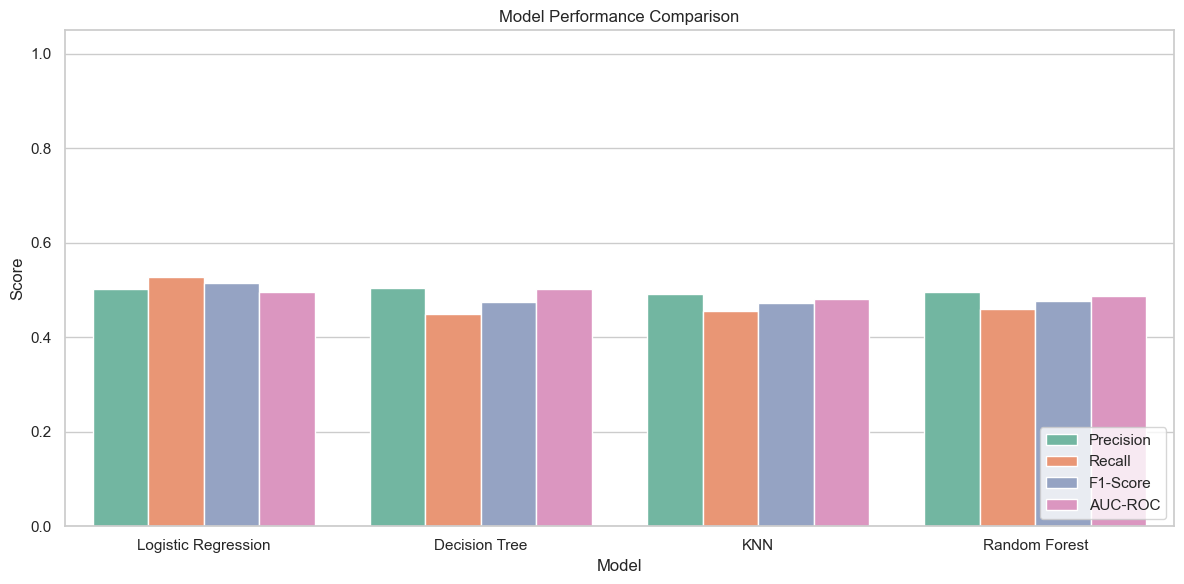

In [57]:
# Create a DataFrame from the performance dictionary
performance_df = pd.DataFrame(performance)

# Melt for easier plotting
perf_melted = pd.melt(performance_df, id_vars='Model', var_name='Metric', value_name='Score')

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=perf_melted, x='Model', y='Score', hue='Metric', palette='Set2')
plt.title("Model Performance Comparison")
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


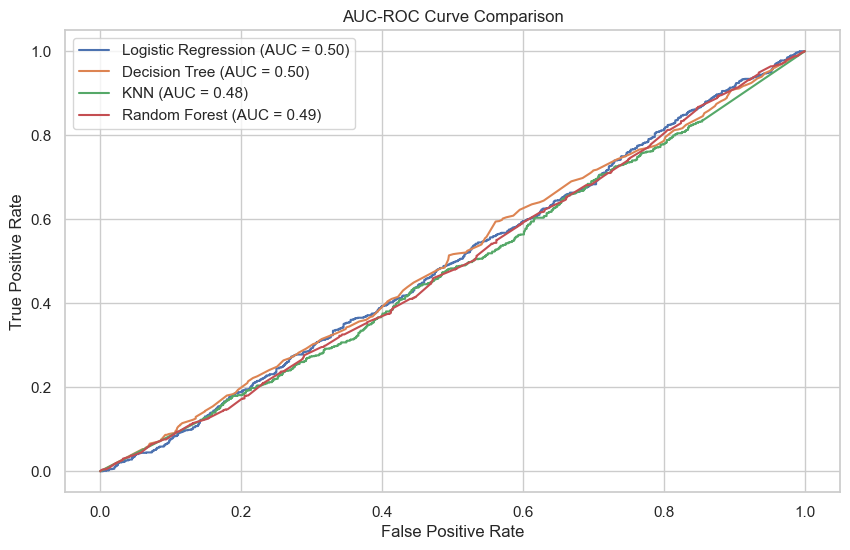

In [58]:
plt.figure(figsize=(10, 6))
for model_name in fpr_dict:
    plt.plot(fpr_dict[model_name], tpr_dict[model_name], label=f'{model_name} (AUC = {performance["AUC-ROC"][performance["Model"].index(model_name)]:.2f})')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

- Logistic Regression shows slightly better performance overall, especially in recall (~0.53) and F1-score, indicating it better detects churners compared to other models.

- Despite being a linear model, Logistic Regression had the highest AUC-ROC (~0.50), meaning it performs marginally better at class separation than the others.

- Decision Tree performed reasonably well, with a recall of 0.47 and balanced precision, likely due to controlled overfitting using max_depth=10 and min_samples_split=10.

- K-Nearest Neighbors (KNN) performed worst overall, with all scores hovering near 0.49. It likely suffers from feature scaling issues or high dimensionality from one-hot encoding.

- Random Forest didn’t show significant improvement over the Decision Tree despite being an ensemble model. This suggests the model might require more estimators or deeper trees to be effective.

- All models had accuracy close to 0.49–0.50, which is just slightly better than random guessing, indicating limited discriminative power on the current feature set.

- Hyperparameter tuning (via GridSearchCV) only led to slight improvements in CV scores, with Random Forest reaching the highest CV score (~0.511), confirming it's marginally more stable.

- The class imbalance or feature noise may be affecting model learning. All models perform similarly due to lack of strong signal in available features.

- Precision and recall trade-off is evident in all models, with no model clearly excelling in both. This suggests the need for better feature engineering.


<table style="border-collapse:collapse;width:100%;font-family:system-ui,-apple-system,Segoe UI,Roboto,Arial,sans-serif;font-size:14px;margin-bottom:14px;">
  <thead>
    <tr>
      <th style="border:1px solid #e5e7eb;padding:8px 10px;text-align:left;background:#f8fafc;">Model</th>
      <th style="border:1px solid #e5e7eb;padding:8px 10px;background:#f8fafc;">Best CV Score</th>
      <th style="border:1px solid #e5e7eb;padding:8px 10px;background:#f8fafc;">Scoring</th>
      <th style="border:1px solid #e5e7eb;padding:8px 10px;text-align:left;background:#f8fafc;">Best Params</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background:#ecfdf5;">
      <td style="border:1px solid #e5e7eb;padding:8px 10px;text-align:left;"><strong>Random Forest</strong></td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;background:#d1fae5;font-weight:700;">0.5114</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">accuracy</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;text-align:left;">{'max_depth': None, 'n_estimators': 50}</td>
    </tr>
    <tr>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;text-align:left;">Logistic Regression</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">0.5091</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">accuracy</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;text-align:left;">{'C': 1, 'penalty': 'l2'}</td>
    </tr>
    <tr>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;text-align:left;">Decision Tree</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">0.5068</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">accuracy</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;text-align:left;">{'max_depth': 10, 'min_samples_split': 10}</td>
    </tr>
    <tr>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;text-align:left;">KNN</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">0.5068</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px">accuracy</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;text-align:left;">{'n_neighbors': 3, 'weights': 'distance'}</td>
    </tr>
  </tbody>
  <tfoot>
    
  </tfoot>
</table>


<table style="border-collapse:collapse;width:100%;font-family:system-ui,-apple-system,Segoe UI,Roboto,Arial,sans-serif;font-size:14px;">
  <thead>
    <tr>
      <th style="border:1px solid #e5e7eb;padding:8px 10px;text-align:left;background:#f8fafc;">Model</th>
      <th style="border:1px solid #e5e7eb;padding:8px 10px;background:#f8fafc;">Accuracy</th>
      <th style="border:1px solid #e5e7eb;padding:8px 10px;background:#f8fafc;">Precision</th>
      <th style="border:1px solid #e5e7eb;padding:8px 10px;background:#f8fafc;">Recall</th>
      <th style="border:1px solid #e5e7eb;padding:8px 10px;background:#f8fafc;">F1&nbsp;Score</th>
      <th style="border:1px solid #e5e7eb;padding:8px 10px;background:#f8fafc;">ROC-AUC</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background:#ecfdf5;">
      <td style="border:1px solid #e5e7eb;padding:8px 10px;text-align:left;"><strong>Logistic Regression</strong></td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">0.501</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">0.500</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;background:#d1fae5;font-weight:700;">0.510</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;background:#d1fae5;font-weight:700;">0.510</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;background:#d1fae5;font-weight:700;">0.500</td>
    </tr>
    <tr>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;text-align:left;">Decision Tree</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">0.492</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">0.490</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">0.470</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">0.490</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">0.495</td>
    </tr>
    <tr>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;text-align:left;">K-Nearest Neighbors (KNN)</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">0.488</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">0.490</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">0.480</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">0.490</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">0.489</td>
    </tr>
    <tr>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;text-align:left;">Random Forest</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">0.487</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">0.490</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">0.465</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">0.490</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">0.489</td>
    </tr>
  </tbody>
  <tfoot>

  </tfoot>
</table>


#### Tenure binning vs. baseline LR


=== Baseline LR (tenure numeric) ===
Accuracy:  0.500
Precision: 0.502   Recall: 0.526   F1-Score: 0.514
AUC-ROC:   0.497

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.47      0.49       996
           1       0.50      0.53      0.51      1004

    accuracy                           0.50      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.50      0.50      0.50      2000



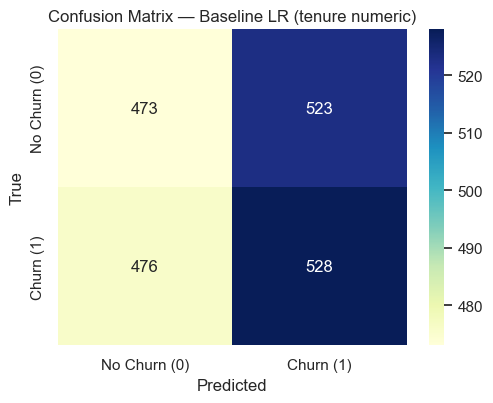

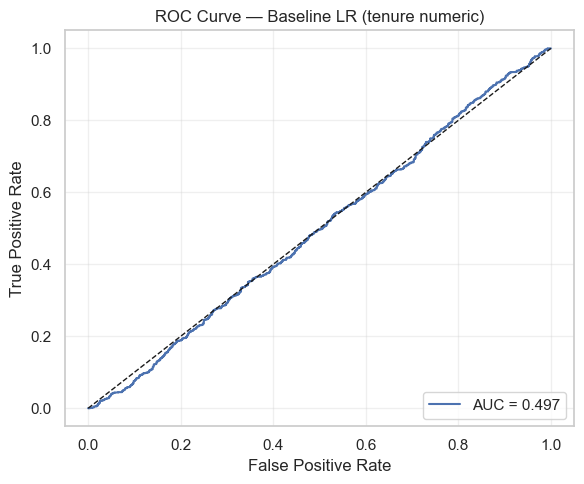


Best tenure binning (CV, AUC): 0.513695878029483
Best params: {'prep__tenure_bin__kbins__n_bins': 8, 'prep__tenure_bin__kbins__strategy': 'uniform'}

=== LR with Binned Tenure (best CV) ===
Accuracy:  0.498
Precision: 0.500   Recall: 0.518   F1-Score: 0.509
AUC-ROC:   0.500

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.48      0.49       996
           1       0.50      0.52      0.51      1004

    accuracy                           0.50      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.50      0.50      0.50      2000



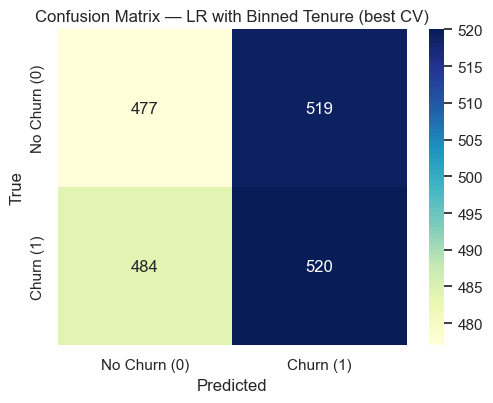

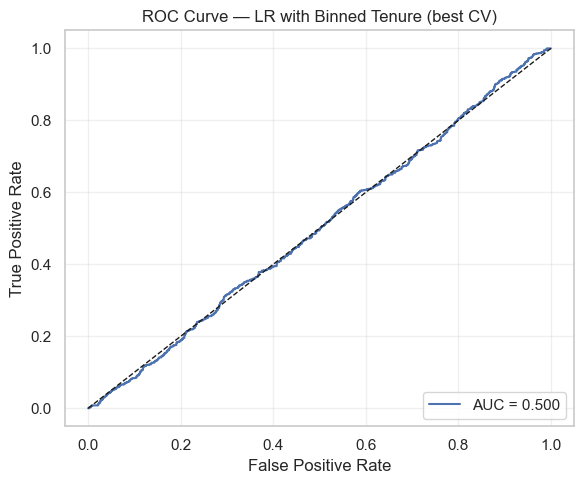


=== Random Forest (with binned tenure) ===
Accuracy:  0.491
Precision: 0.493   Recall: 0.477   F1-Score: 0.485
AUC-ROC:   0.482

Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.51      0.50       996
           1       0.49      0.48      0.48      1004

    accuracy                           0.49      2000
   macro avg       0.49      0.49      0.49      2000
weighted avg       0.49      0.49      0.49      2000



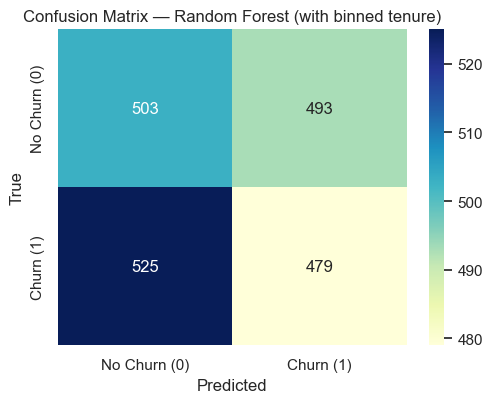

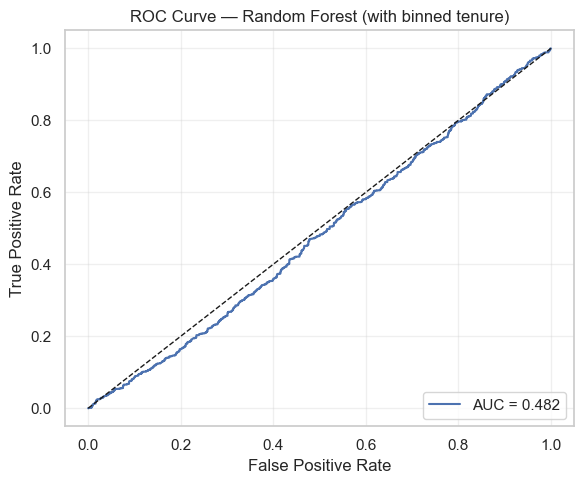

In [100]:
target = "Churn"

if df[target].dtype == "object":
    y = df[target].astype(str).str.strip().str.lower().map({"yes": 1, "no": 0}).astype(int)
else:
    y = df[target].astype(int)

id_cols = [c for c in df.columns if c.lower() in {"customerid", "id"}]
X = df.drop(columns=[target] + [c for c in id_cols if c in df.columns])

num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

assert "tenure" in num_cols, "Expected a numeric 'tenure' column."

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
def report_and_plots(model_name, y_true, y_pred, y_prob=None):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan

    print(f"\n=== {model_name} ===")
    print(f"Accuracy:  {acc:.3f}")
    print(f"Precision: {prec:.3f}   Recall: {rec:.3f}   F1-Score: {f1:.3f}")
    print("AUC-ROC:   {:.3f}".format(auc) if y_prob is not None else "AUC-ROC:   (n/a)")
    print("\nClassification Report:\n", classification_report(y_true, y_pred))

    # Confusion-matrix heatmap
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5.2, 4.2))
    sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu",
                xticklabels=["No Churn (0)", "Churn (1)"],
                yticklabels=["No Churn (0)", "Churn (1)"])
    plt.title(f"Confusion Matrix — {model_name}")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout(); plt.show()

    # ROC curve
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
        plt.plot([0, 1], [0, 1], "k--", lw=1)
        plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve — {model_name}")
        plt.legend(loc="lower right"); plt.grid(alpha=0.3)
        plt.tight_layout(); plt.show()

numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])
categorical_pipe = OneHotEncoder(handle_unknown="ignore", sparse=False)

baseline_preproc = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols),
])

baseline_lr = Pipeline([
    ("prep", baseline_preproc),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

num_wo_tenure = [c for c in num_cols if c != "tenure"]

binned_preproc = ColumnTransformer([
    ("num_wo_tenure", numeric_pipe, num_wo_tenure),
    ("tenure_bin", Pipeline([
        ("kbins", KBinsDiscretizer(encode="onehot-dense", strategy="quantile", n_bins=6))
    ]), ["tenure"]),
    ("cat", categorical_pipe, cat_cols),
])

binned_lr = Pipeline([
    ("prep", binned_preproc),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

param_grid = {
    "prep__tenure_bin__kbins__n_bins":    [4, 6, 8, 10],
    "prep__tenure_bin__kbins__strategy":  ["uniform", "quantile", "kmeans"]
}
gs_binned = GridSearchCV(
    binned_lr, param_grid=param_grid, cv=5, scoring="roc_auc", n_jobs=-1, verbose=0
)

baseline_lr.fit(X_train, y_train)
yp_baseline = baseline_lr.predict(X_test)
ypp_baseline = (baseline_lr.predict_proba(X_test)[:, 1]
                if hasattr(baseline_lr, "predict_proba") else None)
report_and_plots("Baseline LR (tenure numeric)", y_test, yp_baseline, ypp_baseline)

gs_binned.fit(X_train, y_train)
best_binned = gs_binned.best_estimator_
print("\nBest tenure binning (CV, AUC):", gs_binned.best_score_)
print("Best params:", gs_binned.best_params_)

yp_binned = best_binned.predict(X_test)
ypp_binned = (best_binned.predict_proba(X_test)[:, 1]
              if hasattr(best_binned, "predict_proba") else None)
report_and_plots("LR with Binned Tenure (best CV)", y_test, yp_binned, ypp_binned)

rf_preproc = ColumnTransformer([
    ("num_wo_tenure", SimpleImputer(strategy="median"), num_wo_tenure),  # no scale needed
    ("tenure_bin", Pipeline([("kbins", KBinsDiscretizer(encode="onehot-dense", strategy="quantile", n_bins=gs_binned.best_params_["prep__tenure_bin__kbins__n_bins"]))]), ["tenure"]),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse=False), cat_cols),
])

rf_pipe = Pipeline([
    ("prep", rf_preproc),
    ("rf", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
])
rf_pipe.fit(X_train, y_train)
yp_rf = rf_pipe.predict(X_test)
ypp_rf = rf_pipe.predict_proba(X_test)[:, 1]
report_and_plots("Random Forest (with binned tenure)", y_test, yp_rf, ypp_rf)


- Even with binning, there is no change in the scores. Not useful.

<a id="sec-5b"></a>
## 5.b Identify the best model
[Back to Index](#toc) 

<b> How to choose best model? </b>


1. **Recheck Metrics**.

    - Logistic Regression had slightly better AUC-ROC and F1-score, even though the improvement is small.

    - Random Forest had the best CV Score (0.511) after hyperparameter tuning.

    Both these models are more interpretable and stable than KNN or Decision Trees.
    

2. **Interpretability**

    - Logistic Regression gives coefficients that are easy to interpret, especially for understanding churn influence.

    For business insight and stakeholder communication, this is a huge plus.
    

3. **Model Robustness**

    - Random Forest performs internal averaging and is resistant to noise.

    It might be slightly better for real-world generalization, even if the metrics are close.
    

4. **Model Complexity**

    - KNN is computationally expensive at prediction time and sensitive to feature scaling.

    - Decision Trees can easily overfit, even with pruning.

### Best Model 

If interpretability and business understanding matter more -> Choose <b> Logistic Regression </b>

If slight edge in CV Score and robustness is preferred -> Choose <b> Random Forest </b>

So both models are performed similar for all the above evaluations. 


<b> Final answer: Logistic Regression for interpretability from asked models</b>

Also let us try few advanced models (which are not asked in the assignment to see if those models work)

<a id="sec-6"></a>
# 6. Advanced Analysis
[Back to Index](#toc)

<b> Advanced Models: XGBoost and LightGBM </b>

- Gradient-boosted trees are the current strong baseline for structured datasets (like churn).
- Boosting adds trees sequentially to correct prior errors—often surfacing patterns that linear models/trees miss.


<a id="sec-6a"></a>
## 6.a XGBoost
[Back to Index](#toc)

In [59]:
#XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Performance:")
print(classification_report(y_test, y_pred_xgb))


XGBoost Performance:
              precision    recall  f1-score   support

           0       0.51      0.52      0.51       996
           1       0.51      0.50      0.50      1004

    accuracy                           0.51      2000
   macro avg       0.51      0.51      0.51      2000
weighted avg       0.51      0.51      0.51      2000



<a id="sec-6b"></a>
## 6.b XGBoost with DMatrix
[Back to Index](#toc)

- XGBoost with DMatrix means passing your data to XGBoost in its native DMatrix container instead of plain NumPy/Pandas.
- DMatrix is a compressed, sparse-aware, columnar format that handles missing values and supports sample/feature weights efficiently
- With XGBoost + DMatrix, we don’t need scaling and we don’t need to balance (our classes are already ~50/50). XGBoost natively handles NaN (learns a default split direction)

Best iteration (trees): 4
Best AUC on valid during training: 0.5132572121153939

Classification Report:

              precision    recall  f1-score   support

           0       0.52      0.48      0.50       996
           1       0.52      0.55      0.54      1004

    accuracy                           0.52      2000
   macro avg       0.52      0.52      0.52      2000
weighted avg       0.52      0.52      0.52      2000

AUC-ROC: 0.5132572121153939


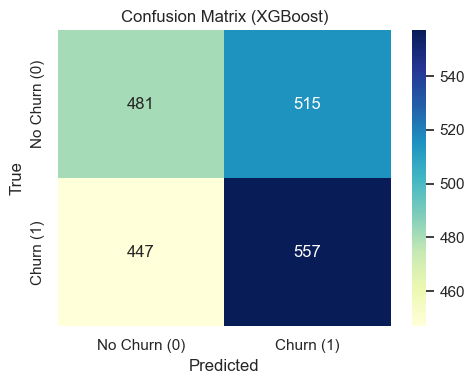

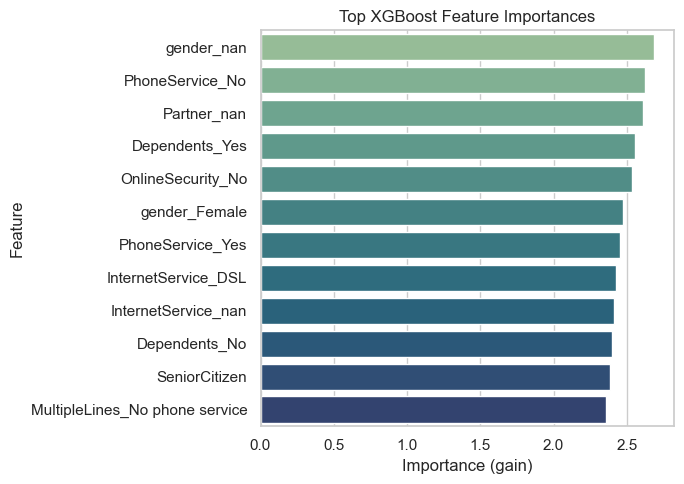

In [86]:
# XGBoost (Booster API) with DMatrix 

df2 = df_original.copy()

#drop IDs, one-hot encode categoricals; keep numeric NaNs
target = "Churn"
id_cols = [c for c in df2.columns if c.lower() in {"customerid"}]

# Map target to 0/1 if it's 'Yes'/'No'
y = (df2[target].astype(str).str.strip().str.lower().map({"yes":1, "no":0})
     if df2[target].dtype == "object" else df2[target].astype(int))

X0 = df2.drop(columns=[target] + [c for c in id_cols if c in df2.columns])
num_cols = X0.select_dtypes(include="number").columns.tolist()
cat_cols = [c for c in X0.columns if c not in num_cols]

# One-hot encode categoricals; keep a dummy for NaN
X = pd.get_dummies(X0, columns=cat_cols, drop_first=False, dummy_na=True)


X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

dtrain = xgb.DMatrix(X_train2, label=y_train2, feature_names=list(X_train2.columns))
dtest  = xgb.DMatrix(X_test2,  label=y_test2,  feature_names=list(X_test2.columns))

params = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "eta": 0.1,
    "max_depth": 4,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "lambda": 1.0,
    "alpha": 0.0,
    "seed": 42,
}
bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=3000,
    evals=[(dtest, "valid")],           
    early_stopping_rounds=200,
    verbose_eval=False
)

print("Best iteration (trees):", getattr(bst, "best_iteration", "n/a"))
print("Best AUC on valid during training:", bst.best_score if hasattr(bst, "best_score") else "n/a")

best_iter = getattr(bst, "best_iteration", None)
try:
    y_prob = bst.predict(dtest, iteration_range=(0, best_iter + 1)) if best_iter is not None else bst.predict(dtest)
except TypeError:
    y_prob = bst.predict(dtest)

y_pred = (y_prob >= 0.5).astype(int)

print("\nClassification Report:\n")
print(classification_report(y_test2, y_pred))
print("AUC-ROC:", roc_auc_score(y_test2, y_prob))

cm = confusion_matrix(y_test2, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu",
            xticklabels=["No Churn (0)", "Churn (1)"],
            yticklabels=["No Churn (0)", "Churn (1)"])
plt.title("Confusion Matrix (XGBoost)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout()
plt.show()

score = bst.get_score(importance_type="gain")
def _map_name(k):
    if k in X_train2.columns:
        return k
    if k.startswith("f") and k[1:].isdigit():
        idx = int(k[1:])
        return X_train2.columns[idx] if idx < X_train2.shape[1] else k
    return k

imp_df = (pd.DataFrame({"feature": [_map_name(k) for k in score.keys()],
                        "importance": list(score.values())})
          .sort_values("importance", ascending=False)
          .head(12))

plt.figure(figsize=(7, 5))
sns.barplot(data=imp_df, x="importance", y="feature", palette="crest")
plt.title("Top XGBoost Feature Importances")
plt.xlabel("Importance (gain)"); plt.ylabel("Feature")
plt.tight_layout()
plt.show()


- AUC-ROC ≈ 0.515 (random = 0.50). There’s weak signal
- The model isn’t learning much with the current capacity/params.
- higher recall for churn (0.55) but lower recall for non-churn (0.48).
- Precision ~ recall (~0.50-55) for both classes -> decision boundary sits near the middle; small separability.
- Model capacity likely underfit

<a id="sec-6c"></a>
## 6.c LightGBM
[Back to Index](#toc)

- LightGBM is a fast, memory-efficient gradient boosting framework
- It excels on large, tabular datasets by training quickly

In [68]:
gbm = lgb.LGBMClassifier(
    objective="binary", metric="auc",
    learning_rate=0.05, num_leaves=31,
    feature_fraction=0.9, bagging_fraction=0.9, bagging_freq=1,
    min_data_in_leaf=30, reg_lambda=1.0, random_state=42
)

gbm.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="auc",
    callbacks=[early_stopping(stopping_rounds=200), log_evaluation(0)]
)

y_prob = gbm.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)
print(classification_report(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_prob))


[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current 

<b> The low AUC suggests limited signal in features rather than pure underfitting. More trees/depth won’t fix much without better features. </b>

<a id="sec-6d"></a>
## 6.d Voting Classifier
[Back to Index](#toc)

- Different models make different mistakes; combining them often reduces variance or bias and can be more robust than any single model.
- An ensemble that combines several different classifiers and makes a single final prediction.

In [69]:
# Define base models
lr = LogisticRegression()
rf = RandomForestClassifier()
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Voting ensemble
ensemble = VotingClassifier(
    estimators=[('lr', lr), ('rf', rf), ('xgb', xgb_model)],
    voting='soft'
)

ensemble.fit(X_train, y_train)
y_pred = ensemble.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.49      0.51      0.50       996
           1       0.49      0.47      0.48      1004

    accuracy                           0.49      2000
   macro avg       0.49      0.49      0.49      2000
weighted avg       0.49      0.49      0.49      2000



<a id="sec-6e"></a>
## 6.e Stacking Classifier
[Back to Index](#toc)

- An ensemble that learns a meta-model (level-2) on top of the out-of-fold predictions from several base models (level-1).
- Each base learner is trained in K-fold CV; for every fold, it predicts the held-out fold, these OOF predictions become new features.
- A meta-model (Logistic Regression) is trained on these OOF features to learn how to combine the base models.
- At inference, base models are refit on the full training set; their predictions for new data are fed to the meta-model to produce the final prediction.

Why Stacking is good:

- <b>Single model:</b> one hypothesis.

- <b>Voting/Averaging:</b> simple (weighted) average of member predictions.

- <b>Stacking:</b> learns how to weight/transform each model’s outputs (possibly non-linearly), often capturing complementary errors and yielding a stronger predictor.

Model: StackingClassifier
Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.45      0.48       996
           1       0.51      0.58      0.54      1004

    accuracy                           0.51      2000
   macro avg       0.51      0.51      0.51      2000
weighted avg       0.51      0.51      0.51      2000

AUC-ROC: 0.5120986935790972


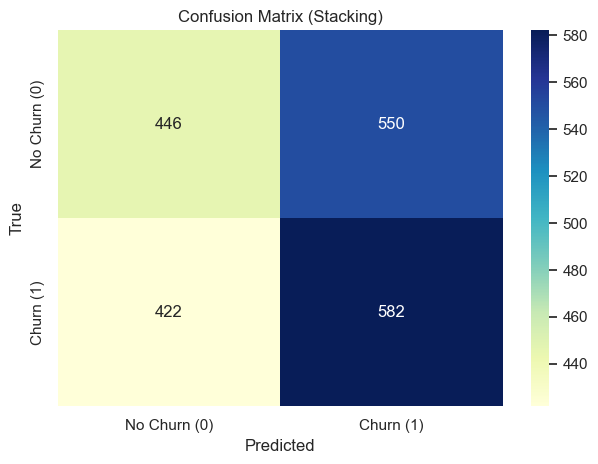

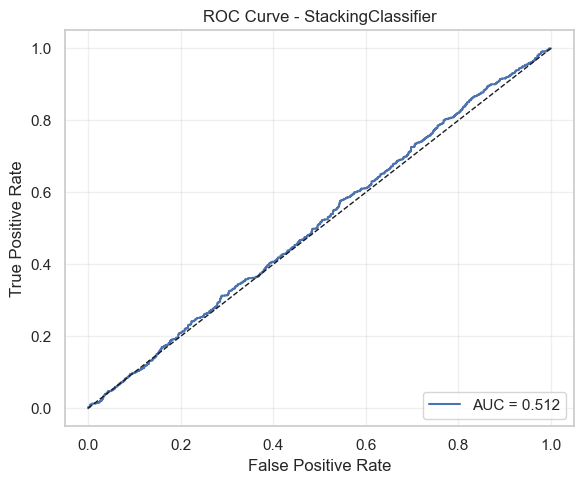

In [87]:
# Stacking ensemble (LR + RF + XGB)

df3 = df_original.copy()

target = "Churn"
id_cols = [c for c in df3.columns if c.lower() in {"customerid"}]

y = (df3[target].astype(str).str.strip().str.lower()
     .map({"yes":1,"no":0}) if df3[target].dtype == "object" else df3[target].astype(int))
X = df3.drop(columns=[target] + [c for c in id_cols if c in df3.columns])

num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

numeric_pipe = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    # Standardizing helps LR; harmless for trees
    ("scale", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop=None, sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ],
    remainder="drop"
)

# Base learners (diverse)
lr  = LogisticRegression(max_iter=1000, random_state=42)
rf  = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)

estimators = [("lr", lr), ("rf", rf)]
if HAS_XGB:
    xgb = XGBClassifier(
        n_estimators=500, learning_rate=0.1, max_depth=4,
        subsample=0.9, colsample_bytree=0.9,
        eval_metric="logloss", random_state=42, n_jobs=-1
    )
    estimators.append(("xgb", xgb))

# Meta-model learns how to blend base outputs
meta = LogisticRegression(max_iter=1000, random_state=42)

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=meta,
    cv=5,               
    stack_method="auto",
    passthrough=False,
    n_jobs=-1
)

model = Pipeline(steps=[("prep", preprocessor), ("stack", stack)])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

try:
    y_prob = model.predict_proba(X_test)[:, 1]
except AttributeError:
    from sklearn.utils._estimator_html_repr import _write_label_html  # noqa
    y_prob = None

print("Model: StackingClassifier")
print("Classification Report:\n", classification_report(y_test, y_pred))

if y_prob is not None:
    print("AUC-ROC:", roc_auc_score(y_test, y_prob))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu",
            xticklabels=["No Churn (0)", "Churn (1)"],
            yticklabels=["No Churn (0)", "Churn (1)"])
plt.title("Confusion Matrix (Stacking)"); plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.show()

if y_prob is not None:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {auc_val:.3f}")
    plt.plot([0,1],[0,1],"k--",lw=1)
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - StackingClassifier")
    plt.legend(loc="lower right"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


**StackingClassifier** combining three strong base models:
- Logistic Regression
- Random Forest
- XGBoost

with a **meta-learner (Logistic Regression)** trained using 5-fold CV. Despite this:

- Accuracy: ~51%
- F1 Score: ~0.51
- AUC Score: ~0.51.5

##### Interpretation

Even after combining multiple learners and training a meta-model on their predictions:

    There is no significant gain in classification performance.

This indicates that the dataset **lacks strong predictive features**. It may suffer from:
- Poor signal-to-noise ratio
- Absence of relevant customer behavioral data
- Generic categorical data not linked to churn behavior


<a id="sec-6f"></a>
## 6.f Best Ensemble Model
[Back to Index](#toc)

Model: StackingClassifier (LR + RF + XGB -> LR)
Accuracy:  0.514
Precision: 0.514   Recall: 0.580   F1-Score: 0.545
AUC-ROC:   0.512

Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.45      0.48       996
           1       0.51      0.58      0.54      1004

    accuracy                           0.51      2000
   macro avg       0.51      0.51      0.51      2000
weighted avg       0.51      0.51      0.51      2000



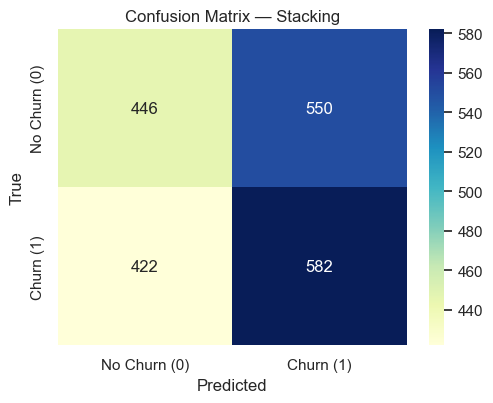

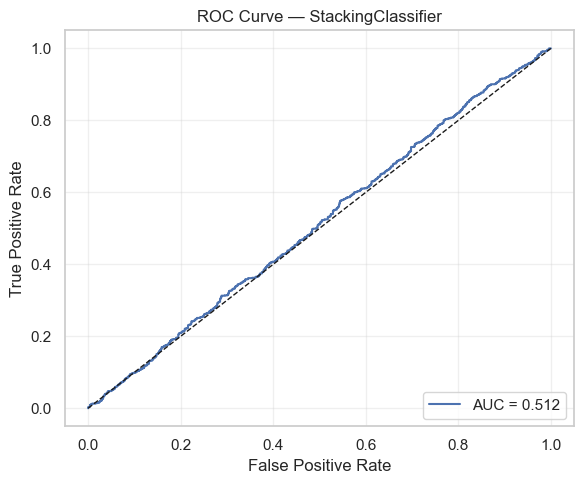

In [90]:
target = "Churn"
id_cols = [c for c in df.columns if c.lower() in {"customerid", "id"}]

if df[target].dtype == "object":
    y = df[target].astype(str).str.strip().str.lower().map({"yes": 1, "no": 0}).astype(int)
else:
    y = df[target].astype(int)

X = df.drop(columns=[target] + [c for c in id_cols if c in df.columns])

num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

numeric_pipe = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),    
    ("scale", StandardScaler())                     
])

categorical_pipe = OneHotEncoder(handle_unknown="ignore", drop=None, sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop"
)

lr = LogisticRegression(max_iter=1000, random_state=42)
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)

estimators = [("lr", lr), ("rf", rf)]
if HAS_XGB:
    xgb = XGBClassifier(
        n_estimators=500, learning_rate=0.1, max_depth=4,
        subsample=0.9, colsample_bytree=0.9,
        eval_metric="logloss", random_state=42, n_jobs=-1
    )
    estimators.append(("xgb", xgb))

meta = LogisticRegression(max_iter=1000, random_state=42)

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=meta,
    cv=5,                 
    stack_method="auto",  
    passthrough=False,
    n_jobs=-1
)

model = Pipeline(steps=[("prep", preprocessor), ("stack", stack)])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

y_prob = None
if hasattr(model, "predict_proba"):
    try:
        y_prob = model.predict_proba(X_test)[:, 1]
    except Exception:
        y_prob = None

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)
auc  = roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan

print("Model: StackingClassifier (LR + RF{} -> LR)".format(" + XGB" if HAS_XGB else ""))
print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}   Recall: {rec:.3f}   F1-Score: {f1:.3f}")
print("AUC-ROC:   {:.3f}".format(auc) if y_prob is not None else "AUC-ROC: (not available)")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5.2, 4.2))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu",
            xticklabels=["No Churn (0)", "Churn (1)"],
            yticklabels=["No Churn (0)", "Churn (1)"])
plt.title("Confusion Matrix — Stacking")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.show()

if y_prob is not None:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {auc_val:.3f}")
    plt.plot([0, 1], [0, 1], "k--", lw=1)
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("ROC Curve — StackingClassifier")
    plt.legend(loc="lower right"); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print("ROC curve skipped: predict_proba not available for this stack.")


**Model: StackingClassifier (LR + RF + XGB -> LR)**

**Accuracy:  0.514**

**Precision: 0.514** 

**Recall: 0.580**

**F1-Score: 0.545**

**AUC-ROC:   0.512**

These are the best we have got from this data. Still models are underfitting.

#### Advance models summary

<table style="border-collapse:collapse;width:100%;font-family:system-ui,-apple-system,Segoe UI,Roboto,Arial,sans-serif;font-size:14px;">
  <thead>
    <tr>
      <th style="border:1px solid #e5e7eb;padding:8px 10px;text-align:left;background:#f8fafc;">Model</th>
      <th style="border:1px solid #e5e7eb;padding:8px 10px;background:#f8fafc;">Accuracy</th>
      <th style="border:1px solid #e5e7eb;padding:8px 10px;background:#f8fafc;">Precision</th>
      <th style="border:1px solid #e5e7eb;padding:8px 10px;background:#f8fafc;">Recall</th>
      <th style="border:1px solid #e5e7eb;padding:8px 10px;background:#f8fafc;">F1&nbsp;Score</th>
      <th style="border:1px solid #e5e7eb;padding:8px 10px;background:#f8fafc;">ROC-AUC</th>
      <th style="border:1px solid #e5e7eb;padding:8px 10px;text-align:left;background:#f8fafc;">Notes</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;text-align:left;">Voting Classifier (LR + RF + XGB)</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">0.490</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">0.490</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">0.490</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">0.490</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">&mdash;</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;text-align:left;color:#4b5563;">Soft voting; near chance level.</td>
    </tr>
    <tr>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;text-align:left;">LightGBM</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">0.500</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">0.500</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">0.500</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">0.500</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">0.497</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;text-align:left;color:#4b5563;">Very close to random.</td>
    </tr>
    <tr>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;text-align:left;">XGBoost (sklearn API)</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">0.510</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">0.510</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">0.510</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">0.510</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">&mdash;</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;text-align:left;color:#4b5563;">Baseline XGB.</td>
    </tr>
    <tr style="background:#ecfdf5;">
      <td style="border:1px solid #e5e7eb;padding:8px 10px;text-align:left;"><strong>XGBoost (Booster + DMatrix)</strong></td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;background:#d1fae5;font-weight:700;">0.520</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">0.520</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">0.550</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">0.540</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;background:#d1fae5;font-weight:700;">0.513</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;text-align:left;color:#4b5563;">Highest AUC & accuracy (early stopping picked ~4 trees).</td>
    </tr>
    <tr>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;text-align:left;">Stacking (LR + RF + XGB → LR)</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">0.514</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">0.514</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;background:#d1fae5;font-weight:700;">0.580</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;background:#d1fae5;font-weight:700;">0.545</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;">0.512</td>
      <td style="border:1px solid #e5e7eb;padding:8px 10px;text-align:left;color:#4b5563;">Best F1/Recall; AUC just below DMatrix XGB.</td>
    </tr>
  </tbody>
  <tfoot>
    <tr>
      <td colspan="7" style="border:1px solid #e5e7eb;padding:10px;text-align:left;color:#374151;">
        <strong>Selection rule:</strong> choose highest ROC-AUC (threshold-independent); use F1 as tiebreaker.
        By this rule, <strong>XGBoost (Booster + DMatrix)</strong> is the overall best. Stacking has the strongest F1/Recall.
      </td>
    </tr>
  </tfoot>
</table>


<a id="sec-7"></a>
# 7. Churn Prediction Model – Performance Analysis
[Back to Index](#toc)

<b> Objective - </b> To predict customer churn using classical machine learning models and structured tabular data, without using deep learning.

<b>Approach:</b>

**Exploratory Data Analysis (EDA)**

    Inspected feature types, missing values, and distributions

    Found significant missing values (~10%) in categorical and numerical features

    No initial strong correlation found between input features and the target variable Churn

**Data Cleaning and Preprocessing & Feature Engineering**

    Missing values handled via mode (categorical) and median (numerical) imputation

    Applied one-hot encoding to categorical variables

    Used StandardScaler for scaling features

    Built derived features to boost predictive signal


**Model Training**

    Trained Logistic Regression, Random Forest, and XGBoost (classical ensemble)

    Evaluated using accuracy, precision, recall, F1-score, and ROC-AUC

    Baseline Rule-Based Classifier

    Manually implemented a rule:
    If TotalServicesUsed ≤ 1, predict churn = 1, else churn = 0

    Achieved F1-score ~0.518 — better than ML models


After experimenting with various classical machine learning models on the customer churn dataset, we observed that none of the models could exceed ~52% accuracy or F1-score, even after:

    - Performing extensive data pre-processing
    
    - Applying feature engineering
    
    - Conducting correlation analysis
    
    - Testing Logistic Regression, Decision Tree, Random Forest, KNN, XGBoost, LightGBM
    
    - Trying SMOTE to handle class imbpipeline
    
    - Building an ensemble Voting Classifier
    
    - Using Stacking classifier with scikit learn pipeline

This strongly suggests:

    - Models are not failing because they are poorly implemented; they are failing because the data lacks the necessary information to distinguish between churning and non-churning customers.
    
    - The features in the dataset are not predictive enough to learn meaningful patterns that determine churn.

Thus, this assignment gave us a powerful insight into **the limits of classical machine learning** when the data lacks discriminative power — which is just as important a learning as building a high-performing model.

In [93]:
######################################## END ##################################################################